# Clasificación: Detección de Fatiga Muscular en Ciclismo
---
**Dataset:** Muscle Fatigue Cycling — `YominE/Muscle_Fatigue_Cycling` (HuggingFace)

**Descripción:** Señales de electromiografía (EMG) registradas en 8 músculos de la pierna dominante de sujetos realizando sprints en bicicleta. El objetivo es clasificar si el sujeto se encuentra en **condición normal (0)** o en **estado de desgaste muscular (1)**.

**Contenido del notebook:**
1. Análisis Preliminar
2. Extracción de Características (Feature Engineering)
3. Análisis Exploratorio de Datos (EDA)
4. Procesamiento de Datos
5. Entrenamiento y Comparación de Modelos
6. Evaluación Final del Mejor Modelo
7. Prueba con Muestra Artificial

## Importación de Librerías

A continuación se importan todas las librerías necesarias para el desarrollo del proyecto:

| Librería | Propósito |
|---|---|
| `pandas` / `numpy` | Manipulación y operaciones numéricas sobre datos |
| `matplotlib` / `seaborn` | Visualización de datos y gráficas estadísticas |
| `scikit-learn` | Preprocesamiento, modelos de clasificación y métricas |
| `scipy.fft` | Transformada de Fourier para extracción de características frecuenciales |
| `datasets` | Carga del dataset desde HuggingFace Hub |
| `tqdm` | Barra de progreso para el ciclo de extracción de ventanas |
| `warnings` / `os` | Manejo de advertencias del sistema y rutas de archivos |

> **Nota:** `matplotlib.use('Agg')` debe declararse **antes** de cualquier `import matplotlib.pyplot` para evitar conflictos con el backend gráfico en entornos sin interfaz visual (servidores, notebooks remotos).

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Manipulación de datos
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento y pipelines
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# Procesamiento de señales
from scipy.fft import fft, fftfreq

# Dataset y utilidades
from datasets import load_dataset
from tqdm import tqdm

# Crear carpetas de salida
for folder in ['graficas_EDA', 'graficas_modelos', 'conclusiones']:
    os.makedirs(folder, exist_ok=True)

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


---
## Punto 1 — Análisis Preliminar

### 1a. Preprocesamiento del Target

El dataset original contiene **3 clases** en la variable `Target`:
- `0` → Condición normal
- `1` → Desgaste muscular leve
- `2` → Desgaste muscular severo (etiquetado alternativo del mismo fenómeno)

Se unifican las clases `1` y `2` en una sola clase `1` (fatiga), convirtiendo el problema en **clasificación binaria**:

| Clase | Significado |
|---|---|
| `0` | Condición normal |
| `1` | Desgaste muscular (cualquier grado) |

**Justificación:** En un sistema de alerta deportiva o clínica, lo relevante es distinguir si **hay o no fatiga**, no su intensidad precisa. Simplificar a binario mejora la robustez del modelo y reduce el riesgo de desbalance entre subclases.

In [2]:
# Cargar dataset desde HuggingFace (una sola vez)
ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = ds['train'].to_pandas()

print("Valores únicos del target ANTES:", df['Target'].unique())
print("Distribución ANTES:")
print(df['Target'].value_counts())

# Unificar clases 1 y 2 → clase 1 (fatiga)
df['Target'] = df['Target'].replace(2, 1)

print("\nValores únicos del target DESPUÉS:", df['Target'].unique())
print("Distribución DESPUÉS:")
print(df['Target'].value_counts())

Valores únicos del target ANTES: [0 1 2]
Distribución ANTES:
Target
0    2127600
1     631200
2     243337
Name: count, dtype: int64

Valores únicos del target DESPUÉS: [0 1]
Distribución DESPUÉS:
Target
0    2127600
1     874537
Name: count, dtype: int64


### 1b. Clasificación de Variables

Se identifican los tipos de cada variable presente en el dataset original:

| Variable | Tipo | Justificación |
|---|---|---|
| `Time` | Numérica continua | Timestamp en segundos, paso fijo de 0.001 s |
| `Right Rectus femoris` | Numérica continua | Señal EMG en mV, valores reales en rango continuo |
| `Left Gluteus maximus` | Numérica continua | Ídem |
| `Left Gastrocnemius medialis` | Numérica continua | Ídem |
| `Left Semitendinosus` | Numérica continua | Ídem |
| `Left Biceps femoris caput longus` | Numérica continua | Ídem |
| `Right Vastus medialis` | Numérica continua | Ídem |
| `Right Tibialis anterior` | Numérica continua | Ídem |
| `Left Gastrocnemius lateralis` | Numérica continua | Ídem |
| `Target` | **Binaria (variable objetivo)** | Solo toma valores 0 ó 1 tras el preprocesamiento |

> ⚠️ La variable `Time` fue **excluida del modelado** porque su relación lineal con el target provocaría *data leakage*: el modelo aprendería que "a mayor tiempo → mayor fatiga" sin capturar ningún patrón fisiológico real.

In [3]:
print("\n--- CLASIFICACIÓN DE VARIABLES ---")
for col in df.columns:
    n_unique = df[col].nunique()
    dtype    = df[col].dtype
    if col == 'Target':
        tipo = "Binaria (Target)"
    elif dtype == 'object' or dtype.name == 'category':
        tipo = "Categórica nominal"
    elif n_unique == 2:
        tipo = "Binaria"
    elif dtype in ['int64', 'float64']:
        tipo = "Numérica continua" if n_unique > 10 else "Numérica discreta"
    else:
        tipo = "Otro"
    print(f"  {col:42s} | dtype: {str(dtype):10s} | únicos: {n_unique:6d} | {tipo}")

print("\nPrimeras filas del dataset:")
df.head()


--- CLASIFICACIÓN DE VARIABLES ---
  Time                                       | dtype: float64    | únicos: 1741599 | Numérica continua
  Right Rectus femoris                       | dtype: float64    | únicos: 3002137 | Numérica continua
  Left Gluteus maximus                       | dtype: float64    | únicos: 3002137 | Numérica continua
  Left Gastrocnemius medialis                | dtype: float64    | únicos: 3002137 | Numérica continua
  Left Semitendinosus                        | dtype: float64    | únicos: 3002137 | Numérica continua
  Left Biceps femoris caput longus           | dtype: float64    | únicos: 3002137 | Numérica continua
  Right Vastus medialis                      | dtype: float64    | únicos: 3002137 | Numérica continua
  Right Tibialis anterior                    | dtype: float64    | únicos: 3002137 | Numérica continua
  Left Gastrocnemius lateralis               | dtype: float64    | únicos: 3002137 | Numérica continua
  Target                             

,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


---
## Punto 2 — Extracción de Características (Feature Engineering)

### 2a. Configuración de Ventanas

La frecuencia de muestreo es **1000 Hz** (confirmada por el paso de la columna `Time`: 0.001 s).  
Se utilizan ventanas de **1 segundo = 1000 muestras** sin solapamiento (hop = 1000).

**Justificación del tamaño de ventana:**
- 1 segundo es el estándar en análisis de fatiga EMG (De Luca, 1997).
- Ventanas < 500 ms pierden resolución frecuencial para estimar MDF con precisión.
- Ventanas > 2 s mezclan segmentos de diferentes estados fisiológicos.

### 2b–2c. Características Extraídas y Justificación

Se extraen **7 características por canal × 8 canales = 56 características** por ventana.

#### Dominio del Tiempo

| Característica | Fórmula | Relevancia fisiológica |
|---|---|---|
| **RMS** | `√(1/N · Σxᵢ²)` | Mide la energía de la señal. **Aumenta** con fatiga por mayor reclutamiento de unidades motoras. |
| **VAR** | `1/N · Σ(xᵢ − μ)²` | Dispersión de la señal. Un músculo fatigado muestra activación más irregular → **mayor varianza**. |
| **ZCR** | `(1/N) · Σ[sign cambia]` | Tasa de cruce por cero. Relacionada con la frecuencia de disparo motora, **disminuye** con fatiga. |
| **MAV** | `1/N · Σ|xᵢ|` | Valor absoluto medio. Indicador clásico de amplitud EMG, correlaciona con la fuerza muscular. |

#### Dominio de la Frecuencia

| Característica | Definición | Relevancia fisiológica |
|---|---|---|
| **MDF** | Frecuencia que divide PSD en dos mitades iguales | **Indicador más importante de fatiga:** cae ~20–30% cuando el músculo se fatiga por acumulación de ácido láctico. |
| **MNF** | Promedio ponderado del espectro: `Σ(fᵢ·Pᵢ)/Σ(Pᵢ)` | Complementa MDF; más sensible a fibras tipo I (lentas). También **disminuye** con fatiga. |
| **PWR** | Potencia espectral total: `Σ|FFT(x)|²` | Energía global del espectro. Aumenta con mayor reclutamiento muscular. |

In [4]:
FS          = 1000   # Frecuencia de muestreo en Hz
WINDOW_SIZE = FS     # Ventana de 1 segundo = 1000 muestras

# Los 8 canales EMG (sin Time ni Target)
emg_cols = [
    'Right Rectus femoris',
    'Left Gluteus maximus',
    'Left Gastrocnemius medialis',
    'Left Semitendinosus',
    'Left Biceps femoris caput longus',
    'Right Vastus medialis',
    'Right Tibialis anterior',
    'Left Gastrocnemius lateralis'
]

def extract_time_features(window):
    """Características en el dominio del tiempo."""
    rms      = np.sqrt(np.mean(window**2))          # Energía
    variance = np.var(window)                        # Dispersión
    zcr      = np.sum(np.diff(np.sign(window)) != 0) / len(window)  # Cruces por cero
    mav      = np.mean(np.abs(window))               # Amplitud media
    return rms, variance, zcr, mav

def extract_freq_features(window, fs=FS):
    """Características en el dominio de la frecuencia."""
    n        = len(window)
    freqs    = fftfreq(n, d=1/fs)
    fft_vals = np.abs(fft(window))**2   # Densidad espectral de potencia
    pos_mask = freqs > 0                # Solo frecuencias positivas
    freqs    = freqs[pos_mask]
    power    = fft_vals[pos_mask]
    total_power      = np.sum(power)
    cumulative_power = np.cumsum(power)
    median_freq = freqs[np.searchsorted(cumulative_power, total_power / 2)]
    mean_freq   = np.sum(freqs * power) / total_power if total_power > 0 else 0
    return median_freq, mean_freq, total_power

# ── Construcción de la base de datos de características ──────
records = []
for start in tqdm(range(0, len(df) - WINDOW_SIZE + 1, WINDOW_SIZE),
                  desc="Extrayendo features por ventana"):
    end       = start + WINDOW_SIZE
    window_df = df.iloc[start:end]
    row       = {}
    for col in emg_cols:
        w     = window_df[col].values
        short = col.replace('Right ', 'R_').replace('Left ', 'L_').replace(' ', '_')
        rms, var, zcr, mav  = extract_time_features(w)
        row[f'{short}_RMS'] = rms
        row[f'{short}_VAR'] = var
        row[f'{short}_ZCR'] = zcr
        row[f'{short}_MAV'] = mav
        mdf, mnf, pwr       = extract_freq_features(w)
        row[f'{short}_MDF'] = mdf
        row[f'{short}_MNF'] = mnf
        row[f'{short}_PWR'] = pwr
    row['Target'] = window_df['Target'].mode()[0]
    records.append(row)

df_features = pd.DataFrame(records)
print(f"\nShape del nuevo dataset de características: {df_features.shape}")
print(f"Columnas generadas ({len(df_features.columns)-1} features + Target):")
print(df_features.columns.tolist())
print(f"\nDistribución del target:")
print(df_features['Target'].value_counts())
df_features.head()

Extrayendo features por ventana: 100%|██████████| 3002/3002 [00:35<00:00, 84.04it/s] 



Shape del nuevo dataset de características: (3002, 57)
Columnas generadas (56 features + Target):
['R_Rectus_femoris_RMS', 'R_Rectus_femoris_VAR', 'R_Rectus_femoris_ZCR', 'R_Rectus_femoris_MAV', 'R_Rectus_femoris_MDF', 'R_Rectus_femoris_MNF', 'R_Rectus_femoris_PWR', 'L_Gluteus_maximus_RMS', 'L_Gluteus_maximus_VAR', 'L_Gluteus_maximus_ZCR', 'L_Gluteus_maximus_MAV', 'L_Gluteus_maximus_MDF', 'L_Gluteus_maximus_MNF', 'L_Gluteus_maximus_PWR', 'L_Gastrocnemius_medialis_RMS', 'L_Gastrocnemius_medialis_VAR', 'L_Gastrocnemius_medialis_ZCR', 'L_Gastrocnemius_medialis_MAV', 'L_Gastrocnemius_medialis_MDF', 'L_Gastrocnemius_medialis_MNF', 'L_Gastrocnemius_medialis_PWR', 'L_Semitendinosus_RMS', 'L_Semitendinosus_VAR', 'L_Semitendinosus_ZCR', 'L_Semitendinosus_MAV', 'L_Semitendinosus_MDF', 'L_Semitendinosus_MNF', 'L_Semitendinosus_PWR', 'L_Biceps_femoris_caput_longus_RMS', 'L_Biceps_femoris_caput_longus_VAR', 'L_Biceps_femoris_caput_longus_ZCR', 'L_Biceps_femoris_caput_longus_MAV', 'L_Biceps_femoris

,R_Rectus_femoris_RMS,R_Rectus_femoris_VAR,R_Rectus_femoris_ZCR,R_Rectus_femoris_MAV,R_Rectus_femoris_MDF,R_Rectus_femoris_MNF,R_Rectus_femoris_PWR,L_Gluteus_maximus_RMS,L_Gluteus_maximus_VAR,L_Gluteus_maximus_ZCR,...,R_Tibialis_anterior_MNF,R_Tibialis_anterior_PWR,L_Gastrocnemius_lateralis_RMS,L_Gastrocnemius_lateralis_VAR,L_Gastrocnemius_lateralis_ZCR,L_Gastrocnemius_lateralis_MAV,L_Gastrocnemius_lateralis_MDF,L_Gastrocnemius_lateralis_MNF,L_Gastrocnemius_lateralis_PWR,Target
0,0.011706,0.000137,0.123,0.008125,46.0,55.440134,68.511599,0.003989,0.000016,0.122,...,94.415585,267.639523,0.025655,0.000658,0.120,0.019441,15.0,41.731575,329.066160,0
1,0.014023,0.000197,0.111,0.010118,54.0,57.772568,98.327307,0.004223,0.000018,0.120,...,93.144298,327.023657,0.031409,0.000986,0.149,0.021678,76.0,78.909921,493.206077,0
2,0.014820,0.000220,0.121,0.010151,50.0,56.108824,109.812089,0.004209,0.000018,0.126,...,92.282627,294.690099,0.026209,0.000687,0.101,0.020389,50.0,55.350345,343.448392,0
3,0.013817,0.000191,0.121,0.009894,49.0,56.535388,95.457741,0.004374,0.000019,0.115,...,91.692974,341.036619,0.021673,0.000470,0.154,0.015846,90.0,80.227837,234.840188,0
4,0.013326,0.000177,0.122,0.009676,47.0,58.254567,88.720844,0.004641,0.000022,0.120,...,84.924397,264.667883,0.025220,0.000636,0.138,0.019283,75.0,70.648947,318.024481,0


---
## Punto 3 — Análisis Exploratorio de Datos (EDA)

### 3a. Señales EMG en el Tiempo

Se grafican los primeros 5 segundos de cada canal para una identificación visual inicial.

**Conclusiones esperadas:**
- Las señales presentan morfología típica de EMG: oscilaciones simétricas alrededor del cero, amplitudes en ±0.5 a ±2 mV.
- Sin drift evidente → buena calidad de adquisición.
- Algunos canales (Rectus femoris, Vastus medialis) muestran mayor amplitud → mayor activación en sprints.
- Contenido frecuencial en rango 20–500 Hz, consistente con EMG de superficie.
- Los primeros instantes muestran baja actividad (reposo), con aumentos abruptos al iniciar el sprint.

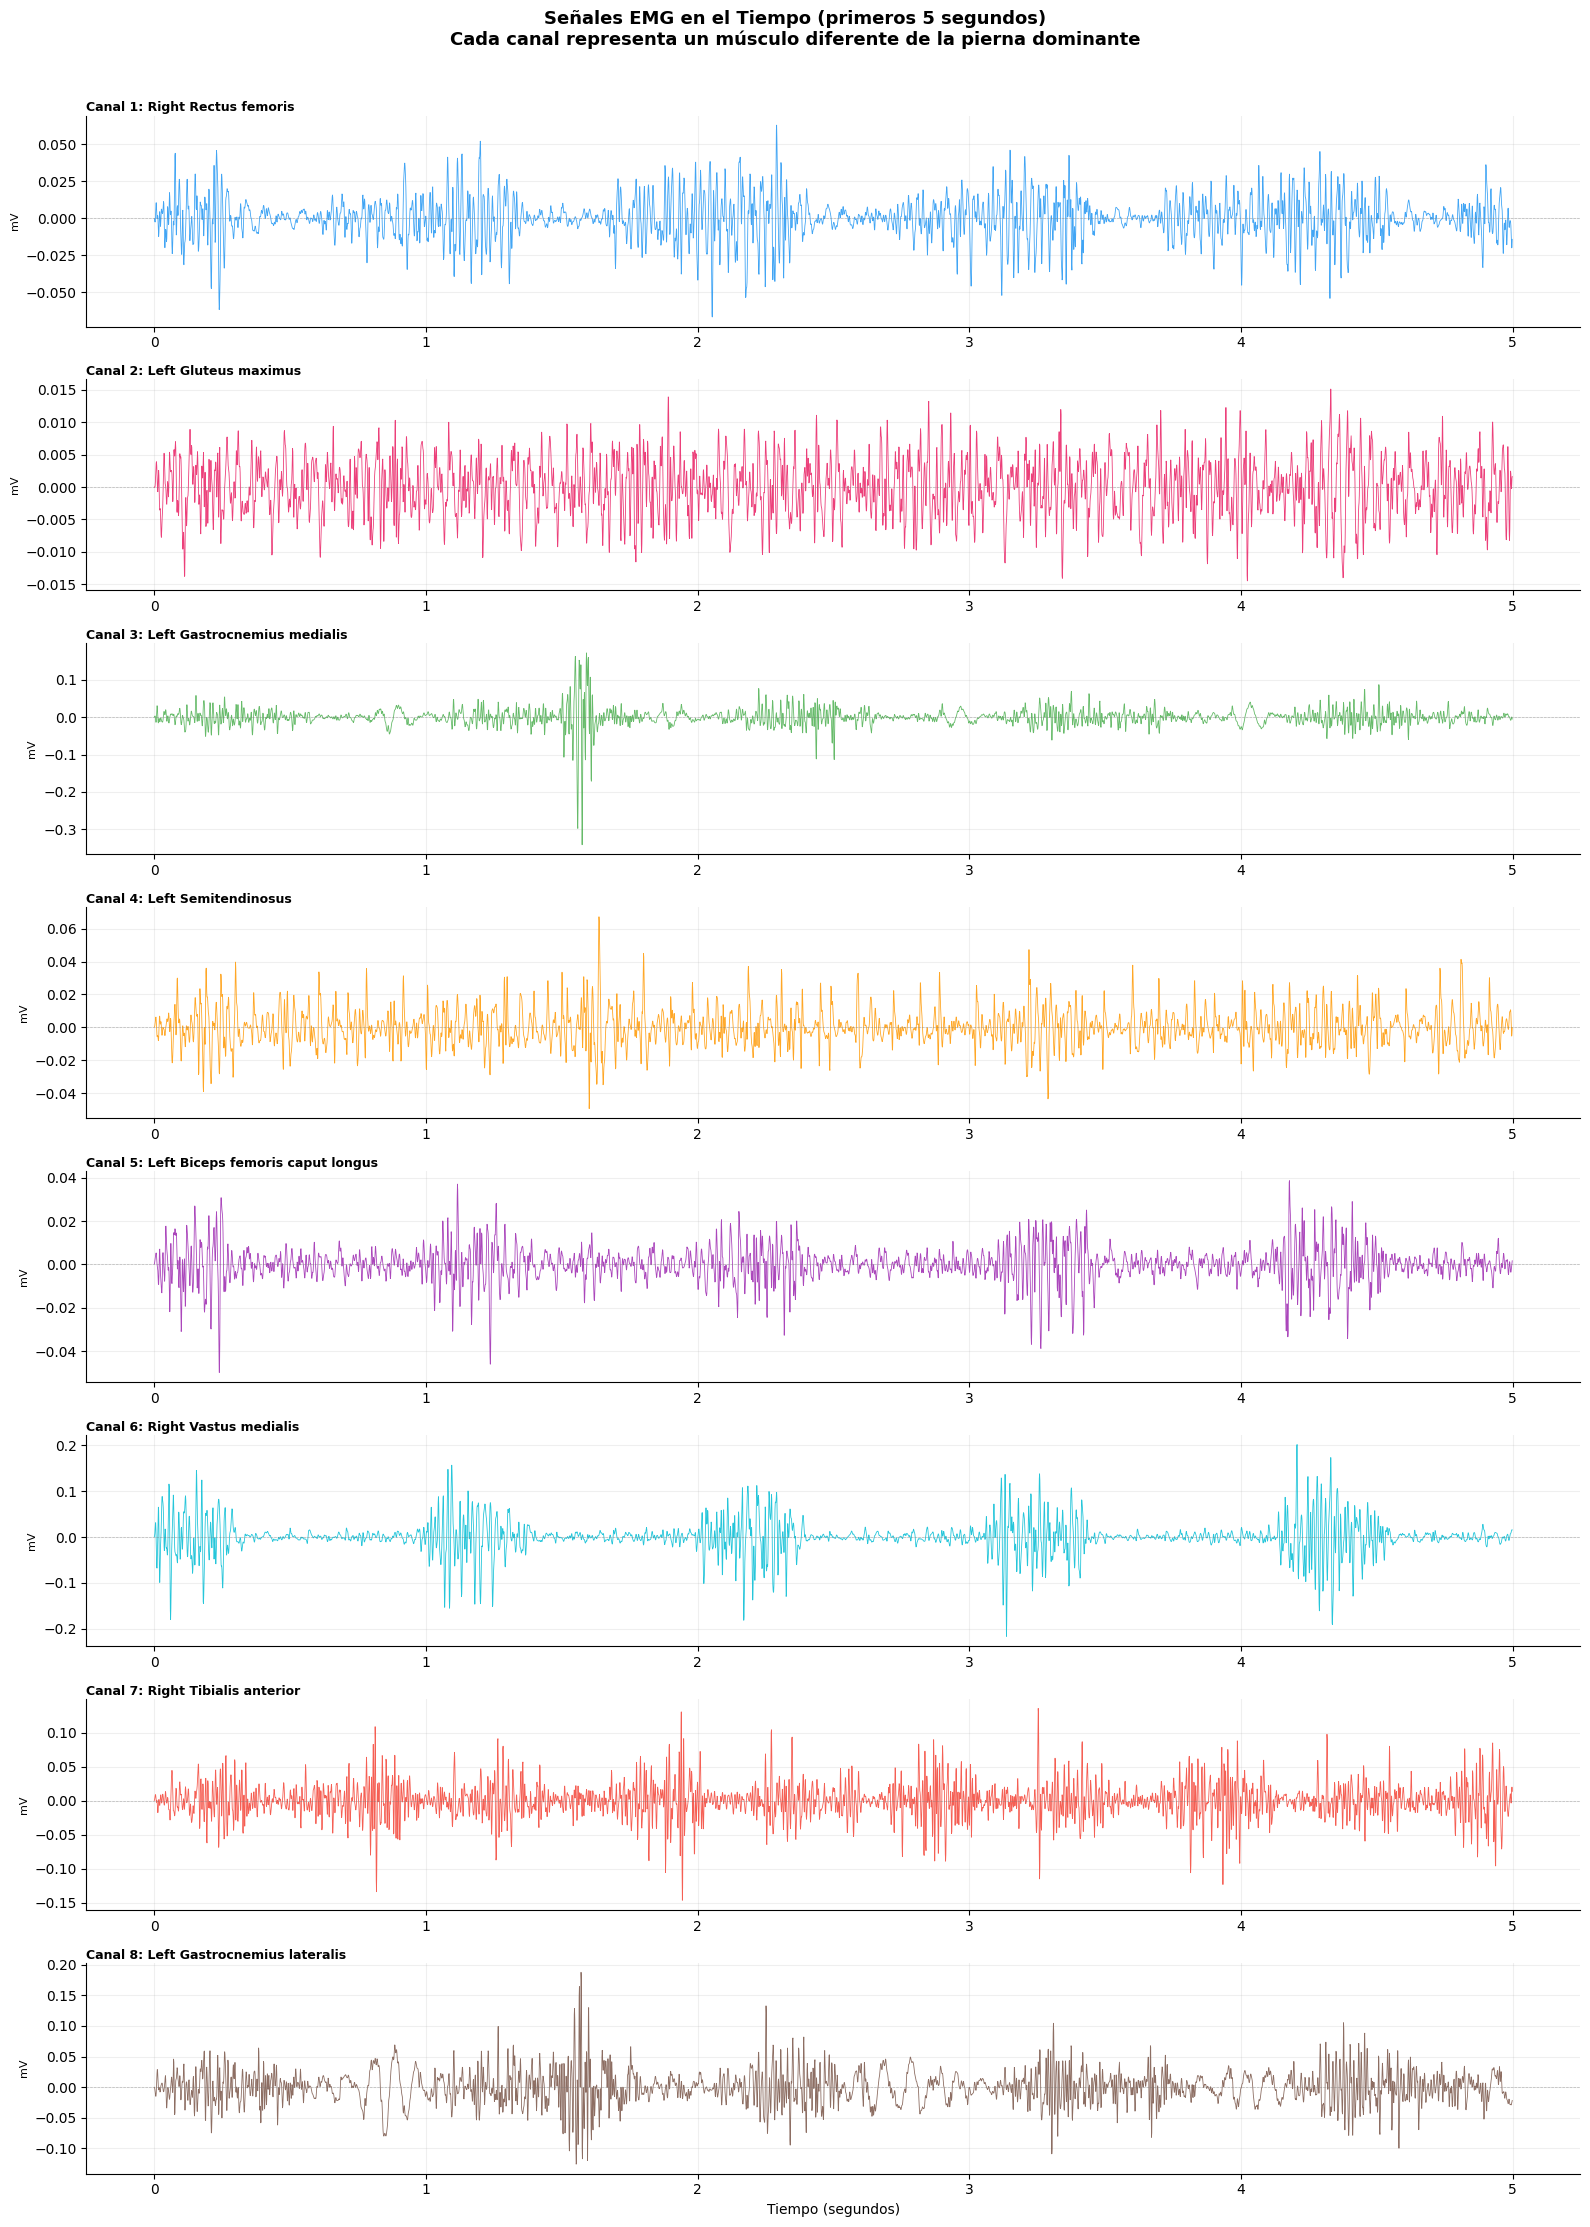

✅ Gráfica guardada: graficas_EDA/señales_tiempo.png


In [5]:
colores = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800',
           '#9C27B0', '#00BCD4', '#F44336', '#795548']

fig, axes = plt.subplots(8, 1, figsize=(16, 22))
fig.suptitle('Señales EMG en el Tiempo (primeros 5 segundos)\n'
             'Cada canal representa un músculo diferente de la pierna dominante',
             fontsize=13, fontweight='bold', y=1.01)
for i, col in enumerate(emg_cols):
    axes[i].plot(df['Time'].values[:5000], df[col].values[:5000],
                 linewidth=0.6, color=colores[i], alpha=0.85)
    axes[i].set_ylabel('mV', fontsize=8)
    axes[i].set_title(f'Canal {i+1}: {col}', fontsize=9, fontweight='bold',
                      loc='left', pad=3)
    axes[i].axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    axes[i].grid(True, alpha=0.2)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
axes[-1].set_xlabel('Tiempo (segundos)', fontsize=10)
plt.tight_layout()
plt.savefig('graficas_EDA/señales_tiempo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada: graficas_EDA/señales_tiempo.png")

### Estadísticos Descriptivos

Se calculan las métricas de resumen del dataset de características para identificar rangos, asimetrías y posibles outliers en cada feature.

In [6]:
print("=" * 60)
print("ESTADÍSTICOS DESCRIPTIVOS DEL DATASET DE CARACTERÍSTICAS")
print("=" * 60)
df_features.describe().round(4)

ESTADÍSTICOS DESCRIPTIVOS DEL DATASET DE CARACTERÍSTICAS


,R_Rectus_femoris_RMS,R_Rectus_femoris_VAR,R_Rectus_femoris_ZCR,R_Rectus_femoris_MAV,R_Rectus_femoris_MDF,R_Rectus_femoris_MNF,R_Rectus_femoris_PWR,L_Gluteus_maximus_RMS,L_Gluteus_maximus_VAR,L_Gluteus_maximus_ZCR,...,R_Tibialis_anterior_MNF,R_Tibialis_anterior_PWR,L_Gastrocnemius_lateralis_RMS,L_Gastrocnemius_lateralis_VAR,L_Gastrocnemius_lateralis_ZCR,L_Gastrocnemius_lateralis_MAV,L_Gastrocnemius_lateralis_MDF,L_Gastrocnemius_lateralis_MNF,L_Gastrocnemius_lateralis_PWR,Target
count,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,...,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000,3002.0000
mean,0.0357,0.0019,0.1089,0.0226,47.5217,54.3020,934.2788,0.0117,0.0005,0.1203,...,70.9990,1625.8607,0.0511,0.0035,0.1367,0.0338,66.4044,71.5626,1756.1328,0.2911
std,0.0244,0.0036,0.0131,0.0153,7.8071,5.8280,1806.7212,0.0177,0.0025,0.0179,...,15.0027,3822.9293,0.0300,0.0044,0.0215,0.0214,16.1452,11.9090,2195.7468,0.4544
min,0.0030,0.0000,0.0630,0.0022,16.0000,22.8263,4.4095,0.0028,0.0000,0.0450,...,35.2897,8.6446,0.0029,0.0000,0.0660,0.0020,12.0000,27.1978,4.1355,0.0000
25%,0.0216,0.0005,0.1000,0.0135,43.0000,51.1753,232.6069,0.0054,0.0000,0.1100,...,65.4039,255.2237,0.0293,0.0009,0.1240,0.0192,62.0000,67.8031,429.5134,0.0000
50%,0.0297,0.0009,0.1090,0.0185,48.0000,54.7947,442.3676,0.0070,0.0000,0.1220,...,72.0947,462.0049,0.0432,0.0019,0.1340,0.0276,69.0000,72.7172,933.6460,0.0000
75%,0.0422,0.0018,0.1180,0.0269,53.0000,58.0410,889.1971,0.0109,0.0001,0.1330,...,79.6418,1096.8831,0.0665,0.0044,0.1480,0.0438,75.0000,77.6801,2211.4570,1.0000
max,0.1907,0.0364,0.1550,0.1284,74.0000,70.8322,18179.8287,0.1964,0.0386,0.1740,...,107.1292,42366.6863,0.1902,0.0362,0.2140,0.1476,113.0000,108.6471,18077.4813,1.0000


### Distribución del RMS por Canal

El **RMS** mide la energía de cada ventana de señal. Distribuciones asimétricas positivas (cola derecha) indican que la mayoría del tiempo los músculos operan con baja activación, con picos de alta activación durante el esfuerzo máximo.

**Interpretación:** Canales con distribuciones más amplias (ej. Gastrocnemius, Rectus femoris) presentan mayor variabilidad de activación — músculos más involucrados en el pedaleo.

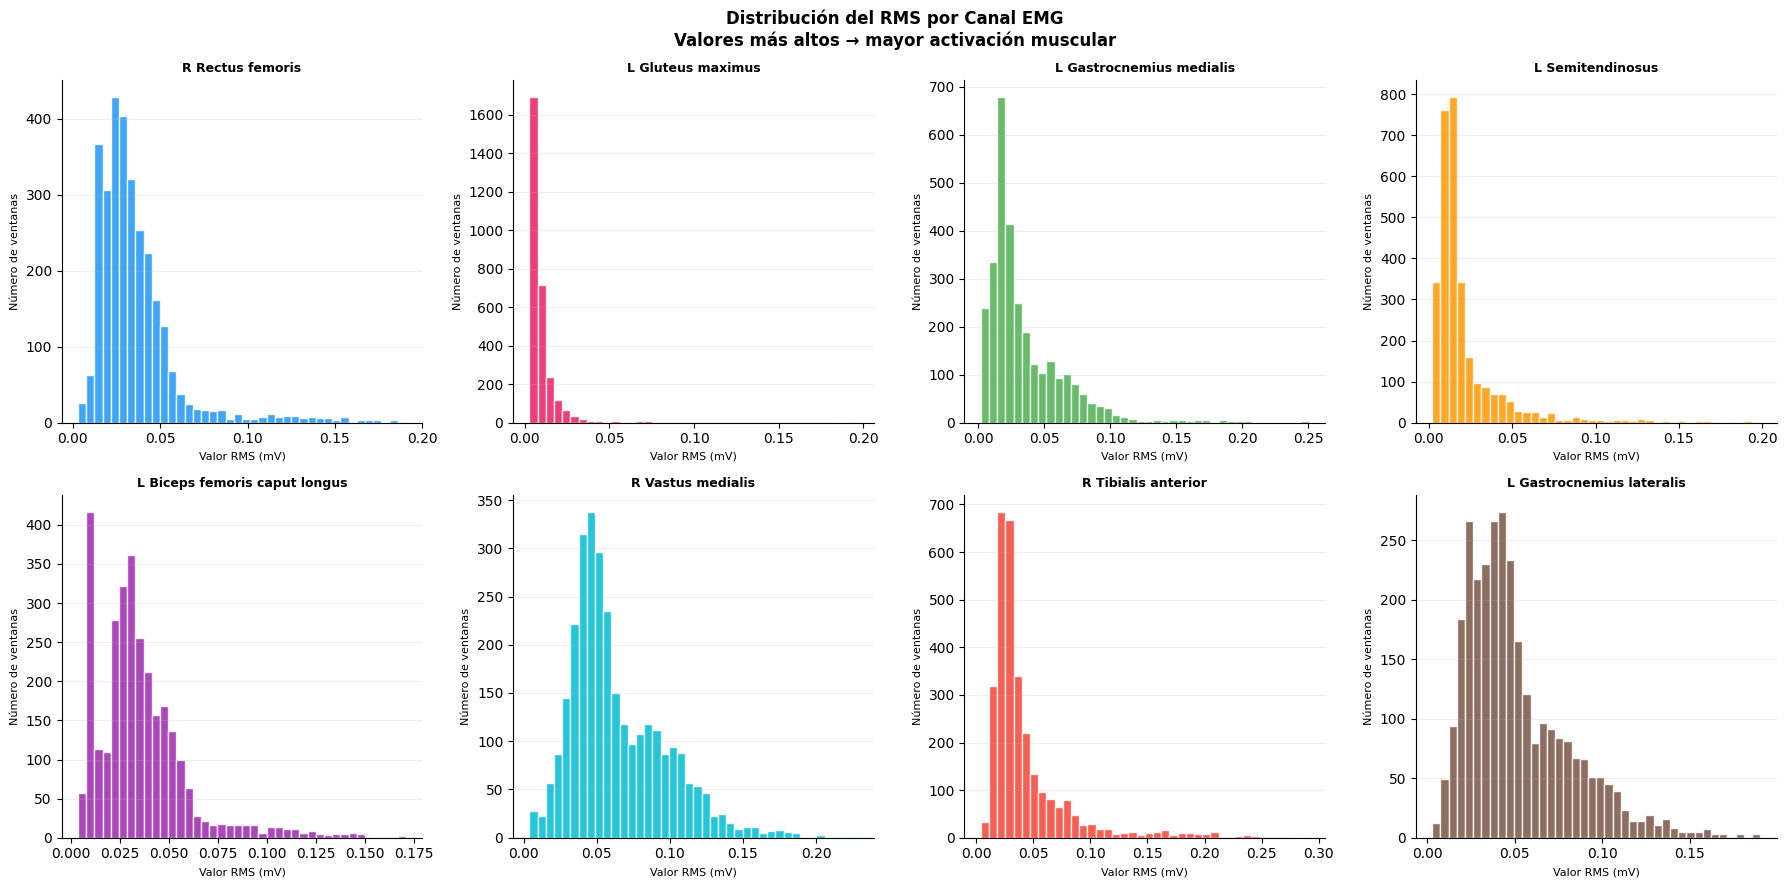

✅ Gráfica guardada.


In [7]:
rms_cols = [c for c in df_features.columns if '_RMS' in c]
mdf_cols = [c for c in df_features.columns if '_MDF' in c]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distribución del RMS por Canal EMG\n'
             'Valores más altos → mayor activación muscular',
             fontsize=12, fontweight='bold')
for i, col in enumerate(rms_cols):
    ax = axes[i//4][i%4]
    ax.hist(df_features[col], bins=40, color=colores[i], edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_RMS','').replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor RMS (mV)', fontsize=8)
    ax.set_ylabel('Número de ventanas', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('graficas_EDA/distribucion_rms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada.")

### Distribución de la Frecuencia Mediana (MDF) por Canal

La **MDF** es el indicador más importante de fatiga muscular. Se concentra normalmente en el rango **50–200 Hz**. Cuando el músculo se fatiga, el espectro de potencia se desplaza hacia frecuencias más bajas → MDF **disminuye**.

**Interpretación:** Si las distribuciones de MDF muestran una cola izquierda o bimodalidad, sugiere presencia de ventanas de fatiga donde la frecuencia mediana cayó.

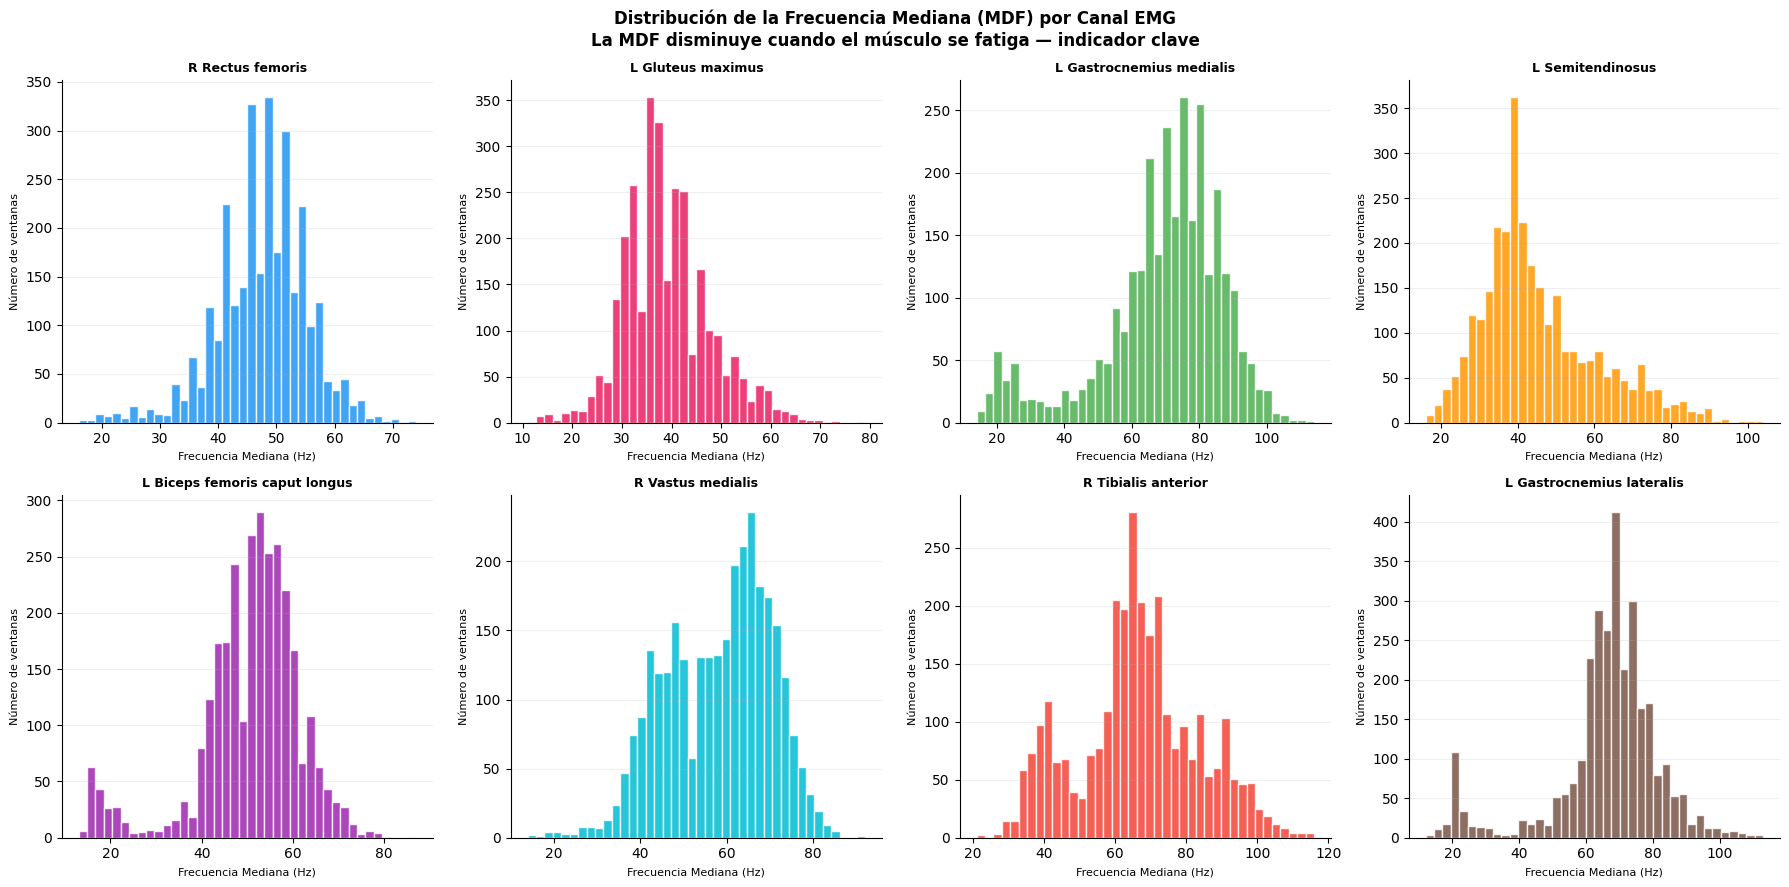

✅ Gráfica guardada.


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distribución de la Frecuencia Mediana (MDF) por Canal EMG\n'
             'La MDF disminuye cuando el músculo se fatiga — indicador clave',
             fontsize=12, fontweight='bold')
for i, col in enumerate(mdf_cols):
    ax = axes[i//4][i%4]
    ax.hist(df_features[col], bins=40, color=colores[i], edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_MDF','').replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Frecuencia Mediana (Hz)', fontsize=8)
    ax.set_ylabel('Número de ventanas', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('graficas_EDA/distribucion_mdf.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada.")

### Balance de Clases

El análisis del balance de clases es fundamental para elegir las métricas de evaluación correctas.

**Interpretación:** Si existe desbalance (más ventanas normales que de fatiga), la **accuracy** puede ser engañosa — un clasificador que predice siempre "normal" tendría alta accuracy pero detectaría 0 casos de fatiga. Por eso se prioriza el **F1-Score** como métrica principal.

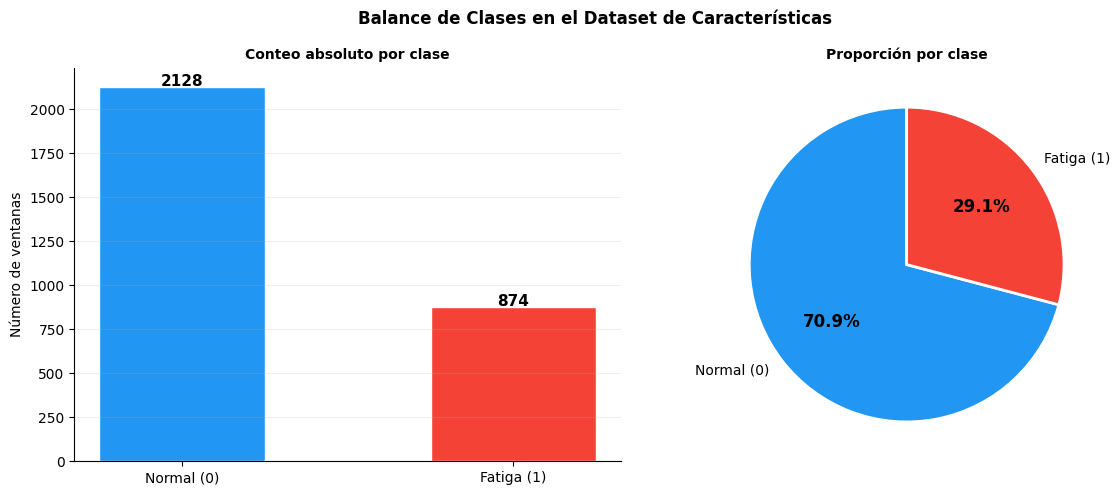

Clase 0 (Normal): 2128 ventanas (70.9%)
Clase 1 (Fatiga): 874 ventanas (29.1%)
Ratio desbalance: 2.43:1


In [9]:
counts = df_features['Target'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Balance de Clases en el Dataset de Características',
             fontsize=12, fontweight='bold')
labels     = ['Normal (0)', 'Fatiga (1)']
colors_pie = ['#2196F3', '#F44336']
bars = axes[0].bar(labels, counts.values, color=colors_pie, edgecolor='white', width=0.5)
axes[0].set_ylabel('Número de ventanas', fontsize=10)
axes[0].set_title('Conteo absoluto por clase', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.2, axis='y')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+5, str(val),
                 ha='center', fontsize=11, fontweight='bold')
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=colors_pie,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for t in autotexts:
    t.set_fontsize(12); t.set_fontweight('bold')
axes[1].set_title('Proporción por clase', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('graficas_EDA/balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Clase 0 (Normal): {counts[0]} ventanas ({counts[0]/len(df_features)*100:.1f}%)")
print(f"Clase 1 (Fatiga): {counts[1]} ventanas ({counts[1]/len(df_features)*100:.1f}%)")
print(f"Ratio desbalance: {counts[0]/counts[1]:.2f}:1")

### Correlaciones entre Características

La matriz de correlación de Pearson permite identificar:
- **Redundancia** entre features (r > 0.9 → poca información adicional).
- **Multicolinealidad** que podría afectar algunos modelos (ej. regresión logística).
- Features **independientes** que aportan información complementaria.

**Interpretación esperada:**
- RMS, MAV y VAR estarán altamente correlacionadas (r > 0.9) — las tres miden variantes de amplitud/energía.
- MDF y MNF también correlacionadas entre sí (r ≈ 0.85–0.95).
- Features del tiempo y frecuencia tendrán correlación moderada (r ≈ 0.3–0.6) → se justifica incluir ambos dominios.

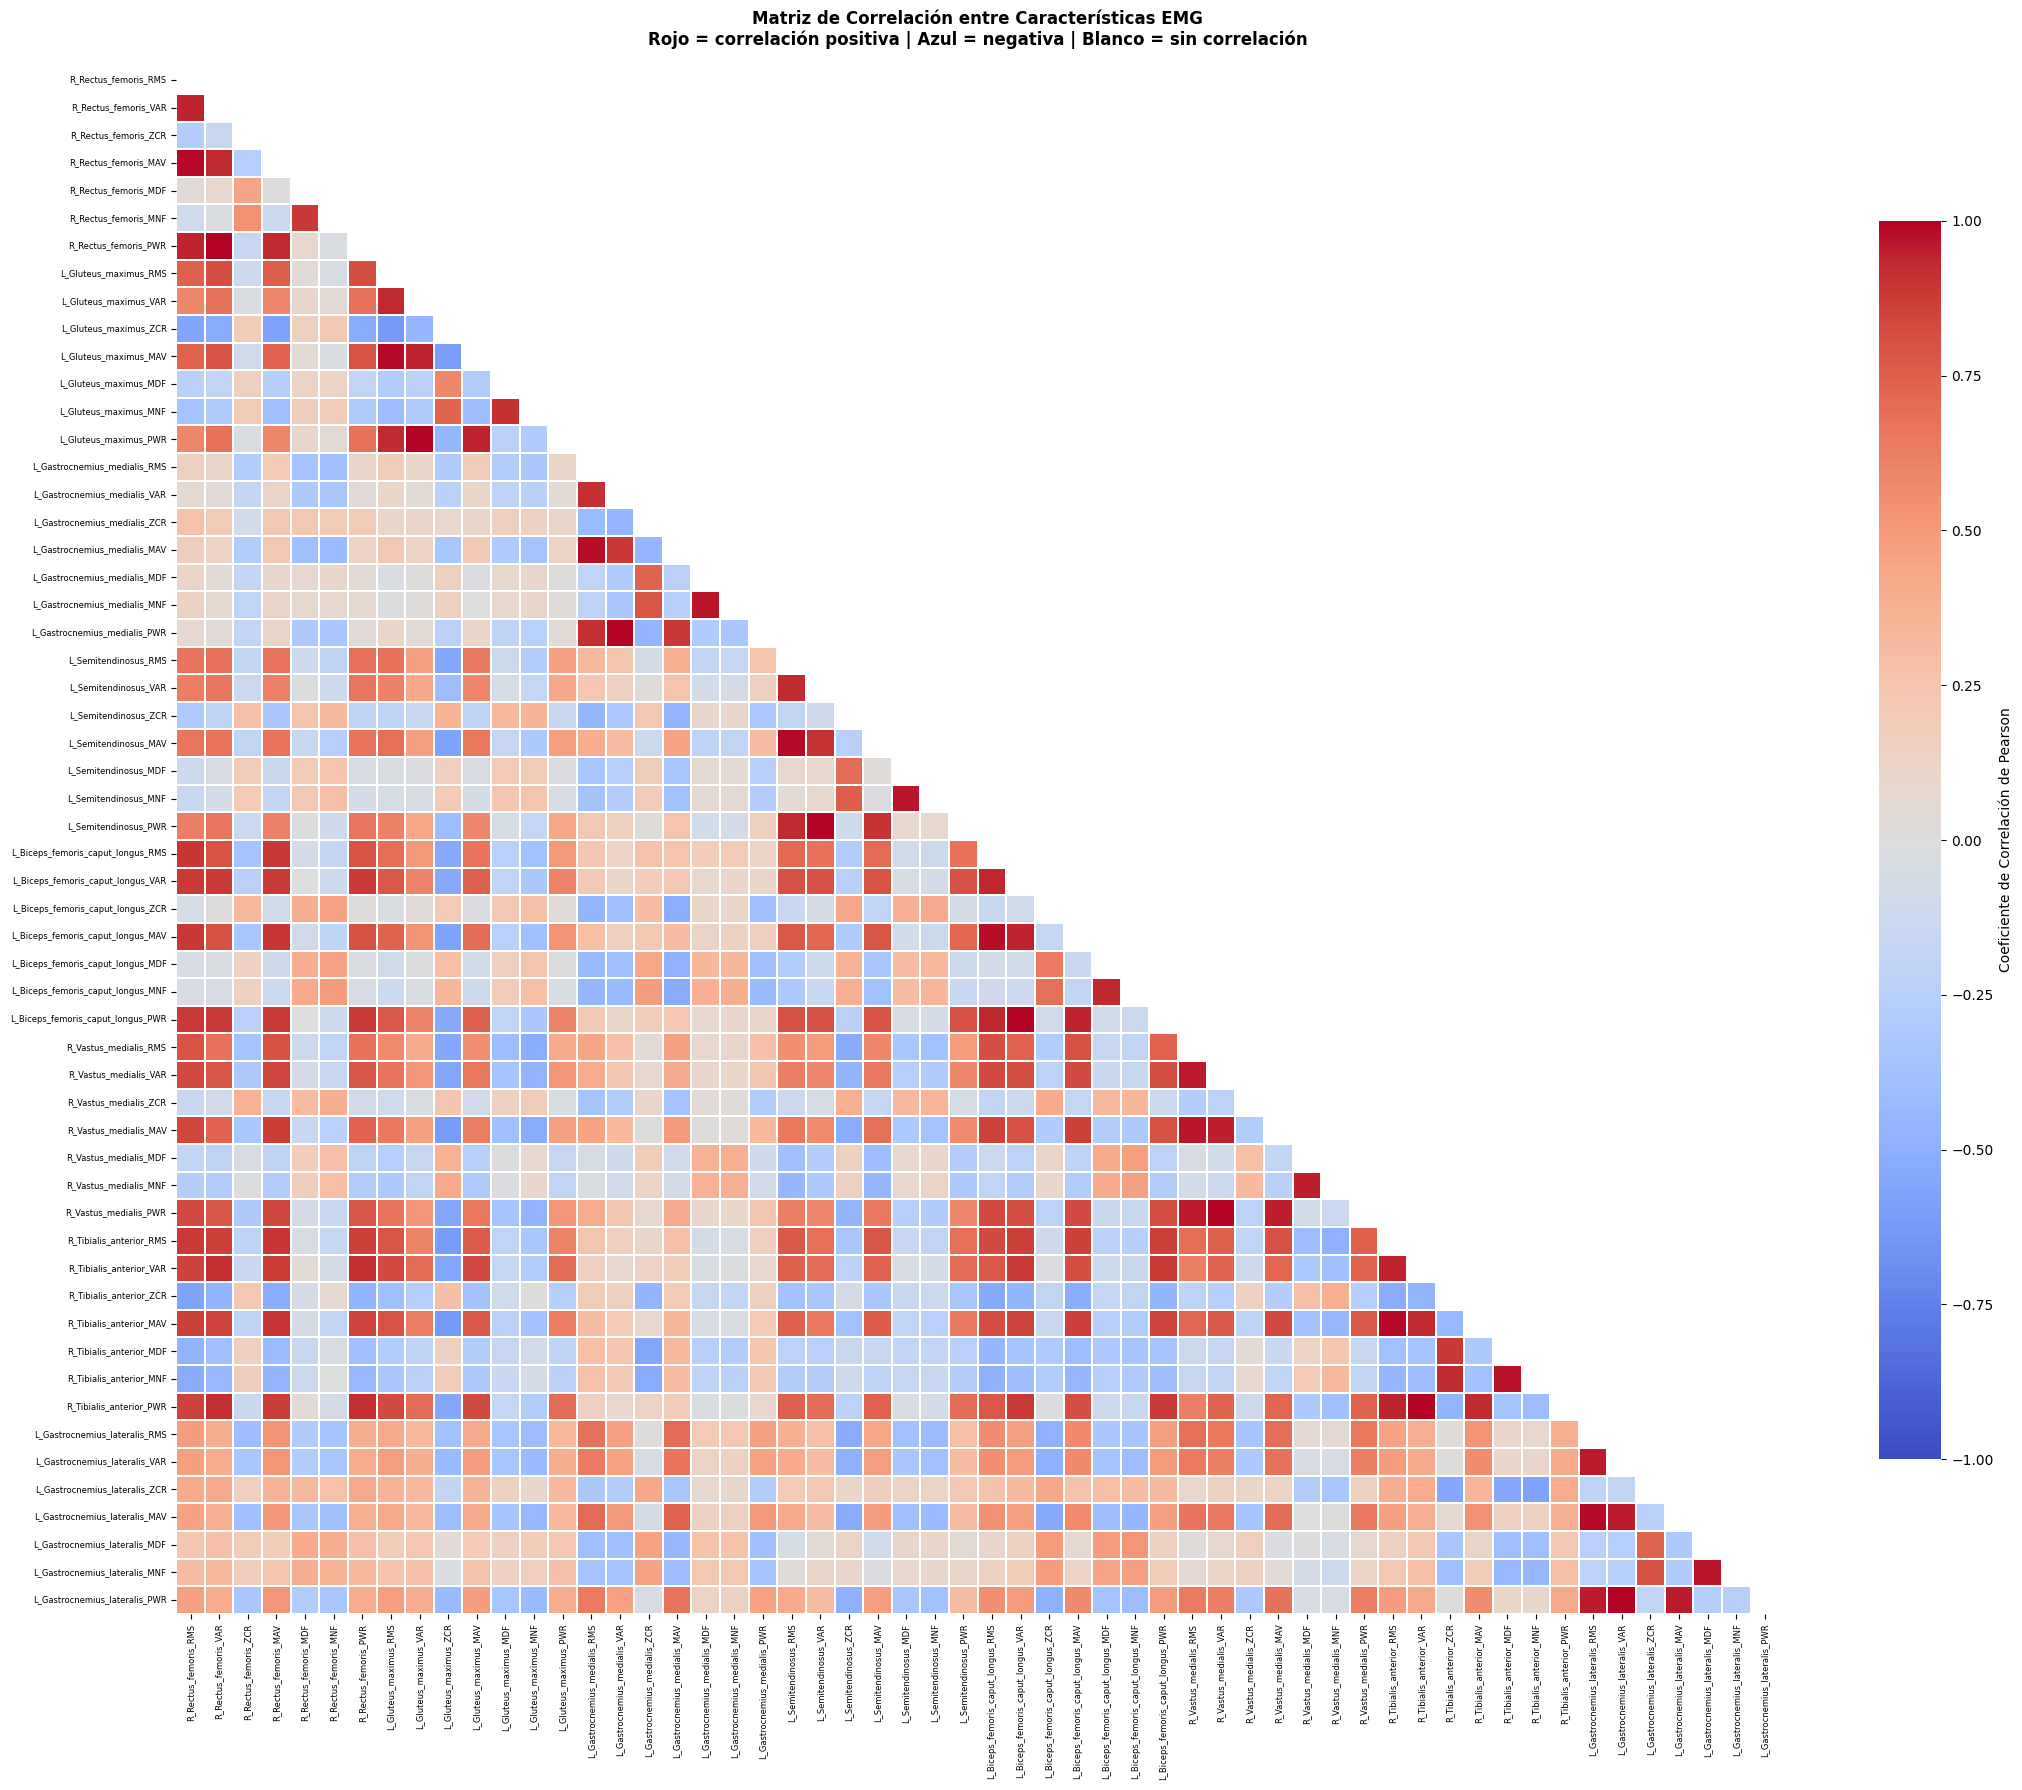


=== TOP 15 CARACTERÍSTICAS MÁS CORRELACIONADAS CON EL TARGET ===
L_Gastrocnemius_medialis_MNF     0.4121
L_Gastrocnemius_medialis_MDF     0.3886
R_Vastus_medialis_MNF            0.2799
R_Vastus_medialis_MDF            0.2514
L_Gastrocnemius_lateralis_RMS    0.2345
R_Tibialis_anterior_MNF          0.2255
R_Tibialis_anterior_ZCR          0.2217
L_Gastrocnemius_lateralis_MAV    0.2117
R_Tibialis_anterior_MDF          0.2015
L_Gastrocnemius_lateralis_PWR    0.1935
L_Gastrocnemius_lateralis_VAR    0.1935
L_Gastrocnemius_medialis_ZCR     0.1755
L_Gastrocnemius_lateralis_ZCR    0.1716
L_Semitendinosus_MDF             0.1602
L_Semitendinosus_RMS             0.1572
Name: Target, dtype: float64


In [10]:
corr_matrix = df_features.drop(columns='Target').corr()
plt.figure(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.1,
            cbar_kws={'label': 'Coeficiente de Correlación de Pearson', 'shrink': 0.8})
plt.title('Matriz de Correlación entre Características EMG\n'
          'Rojo = correlación positiva | Azul = negativa | Blanco = sin correlación',
          fontsize=12, fontweight='bold', pad=15)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.savefig('graficas_EDA/correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n=== TOP 15 CARACTERÍSTICAS MÁS CORRELACIONADAS CON EL TARGET ===")
corr_target = df_features.corr()['Target'].drop('Target').abs().sort_values(ascending=False)
print(corr_target.head(15).round(4))

### Separabilidad entre Clases — Boxplots por Canal

Los boxplots permiten evaluar visualmente cuánto se solapan las distribuciones de cada feature entre la clase Normal (azul) y Fatiga (rojo).

**Interpretación:**
- **RMS:** La clase fatiga tiende a tener RMS más alto (más reclutamiento). Hay solapamiento, pero la mediana es diferente.
- **MDF:** La separabilidad es mayor. Fatiga tiene MDF más baja — confirma el desplazamiento espectral. Este es el indicador más discriminativo del EDA.

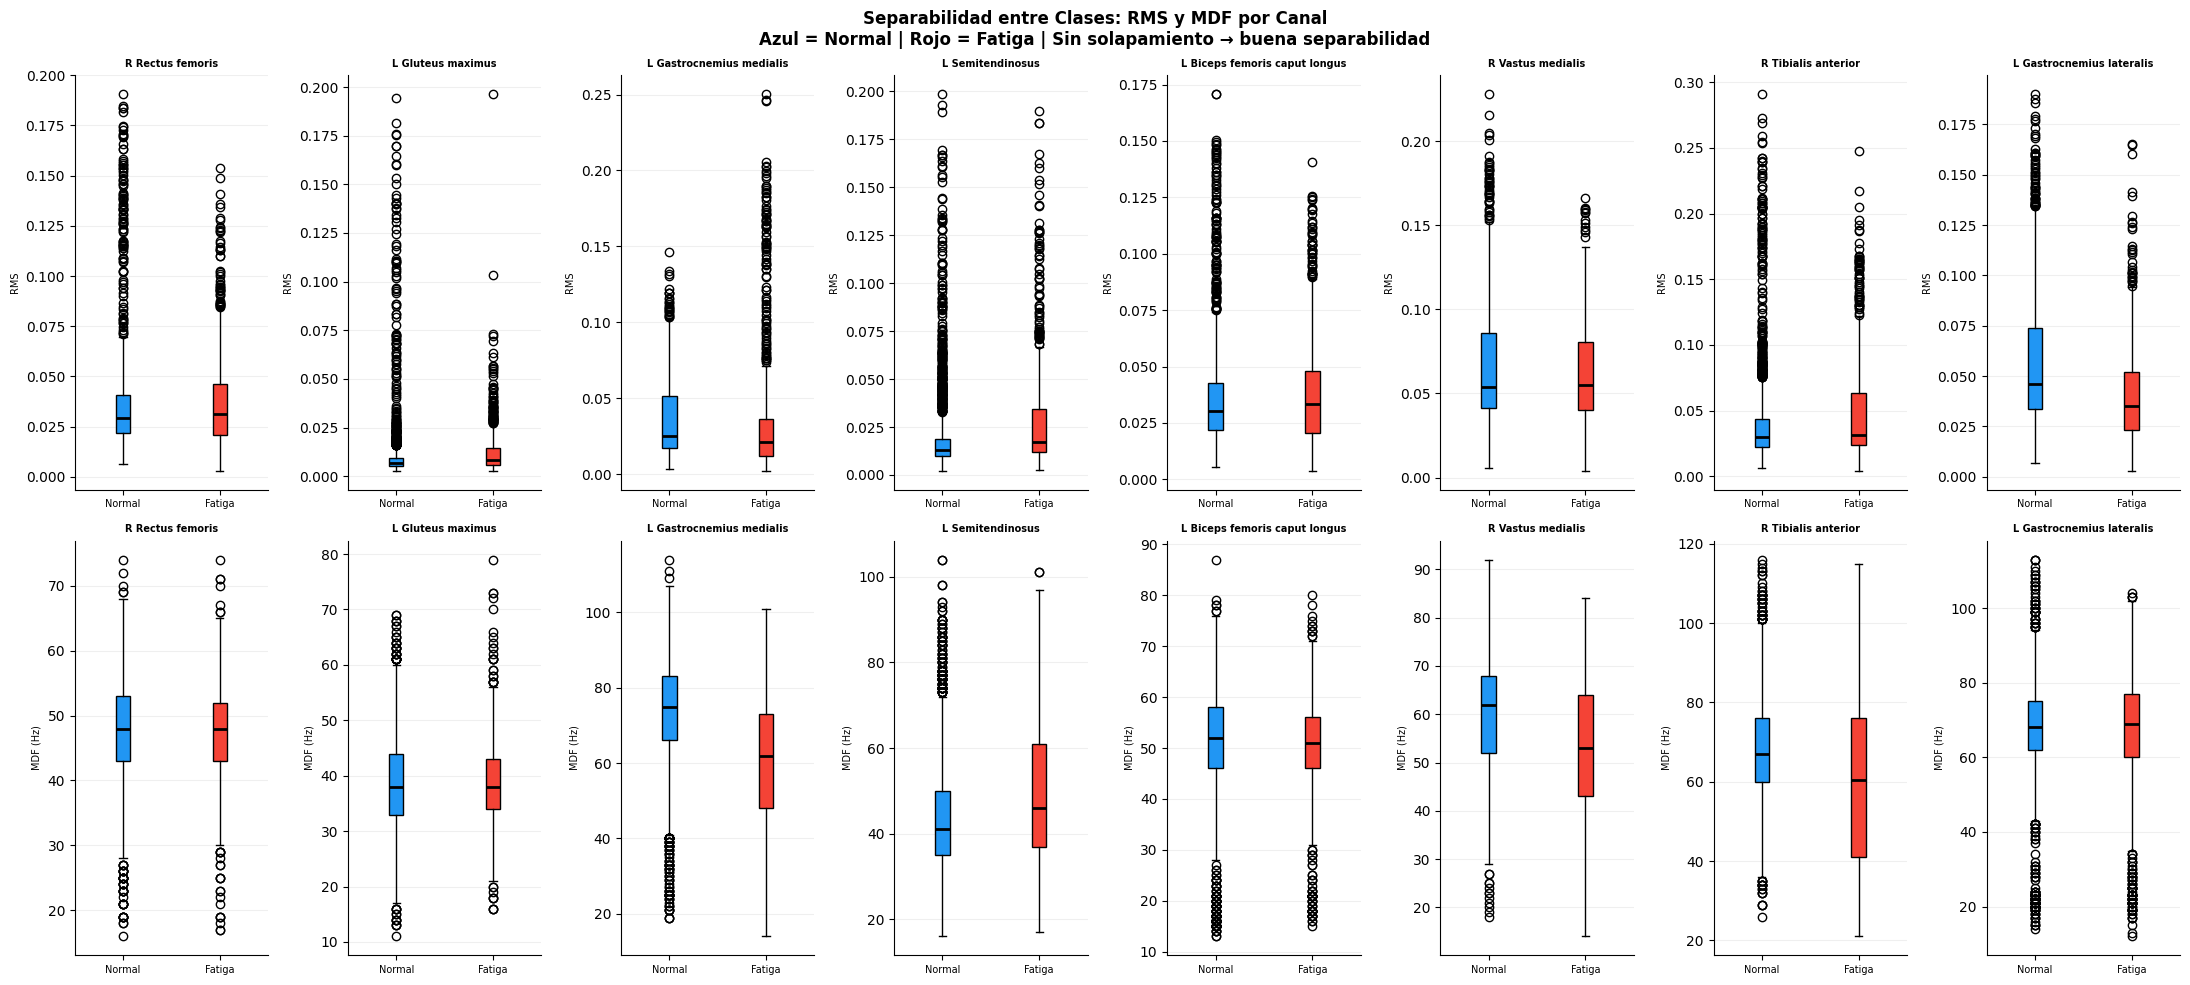

✅ EDA completado. Gráficas guardadas en graficas_EDA/


In [11]:
fig, axes = plt.subplots(2, 8, figsize=(22, 10))
fig.suptitle('Separabilidad entre Clases: RMS y MDF por Canal\n'
             'Azul = Normal | Rojo = Fatiga | Sin solapamiento → buena separabilidad',
             fontsize=12, fontweight='bold')
for i, col in enumerate(rms_cols):
    ax   = axes[0][i]
    d0   = df_features[df_features['Target']==0][col]
    d1   = df_features[df_features['Target']==1][col]
    bp   = ax.boxplot([d0, d1], patch_artist=True,
                      medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    ax.set_title(col.replace('_RMS','').replace('_',' '), fontsize=7, fontweight='bold')
    ax.set_xticklabels(['Normal','Fatiga'], fontsize=7)
    ax.set_ylabel('RMS', fontsize=7)
    ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for i, col in enumerate(mdf_cols):
    ax   = axes[1][i]
    d0   = df_features[df_features['Target']==0][col]
    d1   = df_features[df_features['Target']==1][col]
    bp   = ax.boxplot([d0, d1], patch_artist=True,
                      medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    ax.set_title(col.replace('_MDF','').replace('_',' '), fontsize=7, fontweight='bold')
    ax.set_xticklabels(['Normal','Fatiga'], fontsize=7)
    ax.set_ylabel('MDF (Hz)', fontsize=7)
    ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('graficas_EDA/boxplots_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA completado. Gráficas guardadas en graficas_EDA/")

---
## Punto 4 — Procesamiento de Datos

### 4.1 Manejo de Valores Nulos

Posibles fuentes de NaN en el dataset de características:
- Ventanas con señal constante → ZCR no definido.
- Potencia espectral cero → MNF/MDF no definidas.

Se utiliza `SimpleImputer(strategy='median')` porque la mediana es robusta a outliers, a diferencia de la media que sería arrastrada por valores extremos en señales EMG.

### 4.2 División de Datos: 70 / 15 / 15

| Conjunto | Proporción | Uso |
|---|---|---|
| `X_train` | 70% | Entrenamiento de modelos |
| `X_val` | 15% | Ajuste de hiperparámetros (GridSearch/RandomSearch) |
| `X_test` | 15% | Evaluación final no sesgada |

**Justificación:** Con ~600–800 ventanas totales, esta división da ~500 muestras de entrenamiento suficientes para modelos complejos, y ~100 muestras en val/test para estimaciones estadísticamente estables.  
Se usa `stratify=y` para conservar la proporción de clases en cada split.

### 4.3 Pipeline de Preprocesamiento

```
X_train ──→ SimpleImputer ──→ StandardScaler ──→ X_train_proc
X_val   ──→ transform     ──→ transform      ──→ X_val_proc
X_test  ──→ transform     ──→ transform      ──→ X_test_proc
```

> ⚠️ **Regla de oro del preprocesamiento:** `fit_transform` solo sobre `X_train`. Para `X_val` y `X_test` se usa únicamente `transform`, utilizando los parámetros aprendidos del train. Hacer `fit` sobre val/test introduce *data leakage*.

`StandardScaler` es necesario porque:
- **kNN:** usa distancias euclidianas — sin escalar, features con valores grandes dominan.
- **DNN:** el gradiente descende mejor con entradas normalizadas.

In [12]:
# Separar features y target
X             = df_features.drop(columns='Target')
y             = df_features['Target']
feature_names = X.columns.tolist()

print(f"Total de features: {len(feature_names)}")
print(f"Total de muestras: {len(X)}")
print(f"\nValores nulos en X: {X.isnull().sum().sum()}")

# División 70 / 15 / 15 con estratificación
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp)

print(f"\nDivisión de datos (70/15/15):")
print(f"  X_train : {X_train.shape}  |  clases: {dict(y_train.value_counts())}")
print(f"  X_val   : {X_val.shape}    |  clases: {dict(y_val.value_counts())}")
print(f"  X_test  : {X_test.shape}   |  clases: {dict(y_test.value_counts())}")

# Pipeline: Imputación + Escalado estándar
preprocessing = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# fit_transform sobre train; solo transform sobre val y test
X_train_proc = preprocessing.fit_transform(X_train)
X_val_proc   = preprocessing.transform(X_val)
X_test_proc  = preprocessing.transform(X_test)

print("\n✅ Pipeline de preprocesamiento aplicado correctamente.")

Total de features: 56
Total de muestras: 3002

Valores nulos en X: 0

División de datos (70/15/15):
  X_train : (2100, 56)  |  clases: {0: np.int64(1488), 1: np.int64(612)}
  X_val   : (451, 56)    |  clases: {0: np.int64(320), 1: np.int64(131)}
  X_test  : (451, 56)   |  clases: {0: np.int64(320), 1: np.int64(131)}

✅ Pipeline de preprocesamiento aplicado correctamente.


---
## Punto 5 — Entrenamiento y Comparación de Modelos

Se entrenan **5 clasificadores** con ajuste de hiperparámetros:

| Modelo | Método de búsqueda | Justificación |
|---|---|---|
| k-Nearest Neighbors | GridSearch | Espacio pequeño, búsqueda exhaustiva viable |
| Decision Tree | GridSearch | Pocos hiperparámetros clave |
| Random Forest | RandomizedSearch | Espacio grande; muestreo aleatorio es más eficiente |
| Gradient Boosting | RandomizedSearch | Ídem |
| DNN (MLPClassifier) | GridSearch reducido | Combinaciones de arquitecturas + regularización L2 |

### Funciones Auxiliares

In [14]:
def get_metrics(model, Xd, yd):
    """Calcula Accuracy, Precision, Recall y F1 para un modelo dado."""
    pred = model.predict(Xd)
    return {
        'Accuracy':  round(accuracy_score(yd, pred), 4),
        'Precision': round(precision_score(yd, pred, zero_division=0), 4),
        'Recall':    round(recall_score(yd, pred, zero_division=0), 4),
        'F1':        round(f1_score(yd, pred, zero_division=0), 4),
    }

def plot_learning_curve(model, model_name, Xtr, ytr, Xv, yv):
    """
    Entrena el modelo con subconjuntos crecientes del train set y mide
    accuracy en train y validación. Permite detectar over/underfitting:
    - Brecha grande train >> val al final → overfitting
    - Ambas curvas bajas → underfitting
    - Curvas que convergen → buen ajuste
    """
    np.random.seed(42)
    sizes   = np.linspace(0.1, 1.0, 10)
    tr_accs, va_accs = [], []
    for frac in sizes:
        n   = max(10, int(frac * len(Xtr)))
        idx = np.random.choice(len(Xtr), n, replace=False)
        model.fit(Xtr[idx], ytr.iloc[idx])
        tr_accs.append(accuracy_score(ytr.iloc[idx], model.predict(Xtr[idx])))
        va_accs.append(accuracy_score(yv, model.predict(Xv)))
    x_axis = [int(s * len(Xtr)) for s in sizes]
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, tr_accs, 'o-', color='#2196F3', label='Train',     linewidth=2)
    plt.plot(x_axis, va_accs, 's-', color='#F44336', label='Validación', linewidth=2)
    plt.fill_between(x_axis, tr_accs, va_accs, alpha=0.08, color='gray')
    plt.xlabel('Muestras de entrenamiento', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.title(f'Curva de Aprendizaje – {model_name}', fontsize=12, fontweight='bold')
    plt.legend(fontsize=10); plt.ylim(0.4, 1.05)
    plt.grid(True, alpha=0.3); plt.tight_layout()
    fname = f'graficas_modelos/curva_{model_name.replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    plt.show()
    print(f"  ✅ Curva guardada: {fname}")

results, best_models = {}, {}
print("✅ Funciones auxiliares definidas.")

✅ Funciones auxiliares definidas.


### Modelo 1: k-Nearest Neighbors (kNN) — GridSearch

**Hiperparámetros buscados:**
- `n_neighbors`: número de vecinos (3, 5, 7, 11, 15)
- `weights`: ponderación por distancia o uniforme
- `metric`: distancia euclidiana o Manhattan

> El kNN usa un pipeline propio que incluye `StandardScaler`, por lo que recibe los datos sin escalar y los procesa internamente en cada fold del cross-validation.

[1/5] k-Nearest Neighbors (GridSearch)...
Mejores parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 7, 'clf__weights': 'uniform'}
F1 CV (train): 0.7516


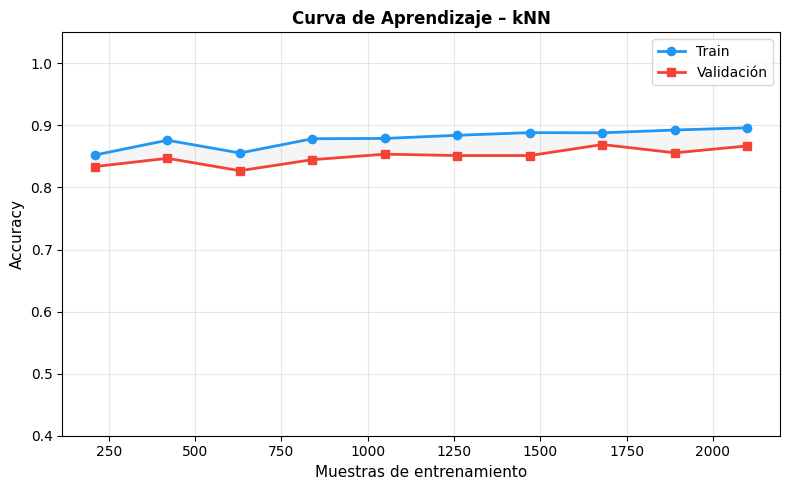

  ✅ Curva guardada: graficas_modelos/curva_kNN.png


In [15]:
print("[1/5] k-Nearest Neighbors (GridSearch)...")
knn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('clf',     KNeighborsClassifier())
])
param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7, 11, 15],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}
gs_knn   = GridSearchCV(knn_pipe, param_grid_knn, cv=5,
                        scoring='f1', n_jobs=-1, verbose=0)
gs_knn.fit(X_train, y_train)   # Pipeline incluye scaler → datos sin procesar
best_knn = gs_knn.best_estimator_
print(f"Mejores parámetros: {gs_knn.best_params_}")
print(f"F1 CV (train): {gs_knn.best_score_:.4f}")

results['kNN'] = {
    'Train': get_metrics(best_knn, X_train, y_train),
    'Val':   get_metrics(best_knn, X_val,   y_val),
    'Test':  get_metrics(best_knn, X_test,  y_test),
}
best_models['kNN'] = best_knn

knn_params = {k.replace('clf__',''):v for k,v in gs_knn.best_params_.items()}
plot_learning_curve(KNeighborsClassifier(**knn_params),
                    'kNN', X_train_proc, y_train, X_val_proc, y_val)

### Modelo 2: Decision Tree — GridSearch

**Hiperparámetros buscados:**
- `max_depth`: profundidad máxima del árbol (None = sin límite → riesgo de overfitting)
- `min_samples_split`: mínimo de muestras para dividir un nodo
- `min_samples_leaf`: mínimo de muestras en hojas (poda)
- `criterion`: función de impureza (Gini o Entropía)

> Los árboles sin restricciones son propensos a memorizar el training set (overfitting). El GridSearch selecciona los parámetros de poda óptimos.

[2/5] Decision Tree (GridSearch)...
Mejores parámetros: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2}
F1 CV (train): 0.7094


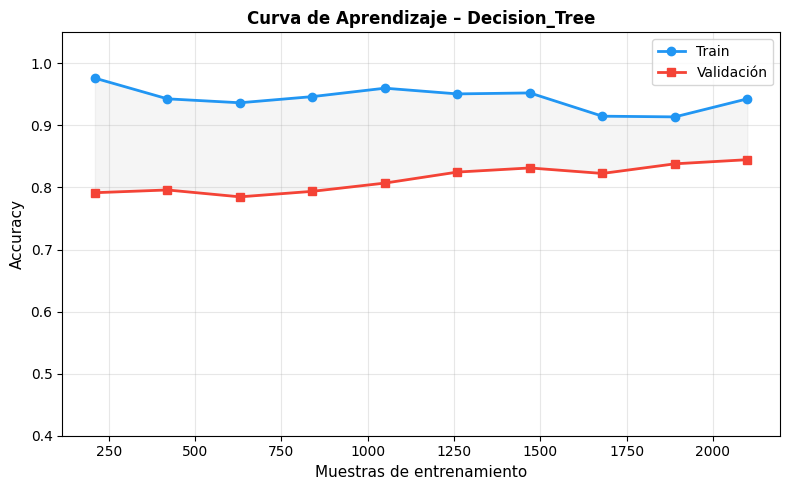

  ✅ Curva guardada: graficas_modelos/curva_Decision_Tree.png


In [16]:
print("[2/5] Decision Tree (GridSearch)...")
param_grid_dt = {
    'max_depth':         [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'criterion':         ['gini', 'entropy']
}
gs_dt   = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid_dt, cv=5, scoring='f1', n_jobs=-1, verbose=0)
gs_dt.fit(X_train_proc, y_train)
best_dt = gs_dt.best_estimator_
print(f"Mejores parámetros: {gs_dt.best_params_}")
print(f"F1 CV (train): {gs_dt.best_score_:.4f}")

results['Decision Tree'] = {
    'Train': get_metrics(best_dt, X_train_proc, y_train),
    'Val':   get_metrics(best_dt, X_val_proc,   y_val),
    'Test':  get_metrics(best_dt, X_test_proc,  y_test),
}
best_models['Decision Tree'] = best_dt

plot_learning_curve(DecisionTreeClassifier(random_state=42, **gs_dt.best_params_),
                    'Decision_Tree', X_train_proc, y_train, X_val_proc, y_val)

### Modelo 3: Random Forest — RandomizedSearch

**Hiperparámetros buscados (30 combinaciones aleatorias):**
- `n_estimators`: número de árboles en el ensemble
- `max_depth`: profundidad máxima de cada árbol
- `min_samples_split` / `min_samples_leaf`: parámetros de poda
- `max_features`: fracción de features consideradas en cada split

> RandomizedSearch es más eficiente que GridSearch para espacios de hiperparámetros grandes, ya que muestrea combinaciones aleatorias y obtiene resultados comparables en menos tiempo (n_iter=30 vs. potencialmente 100+ combinaciones de GridSearch).

[3/5] Random Forest (RandomizedSearch)...
Mejores parámetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
F1 CV (train): 0.7855


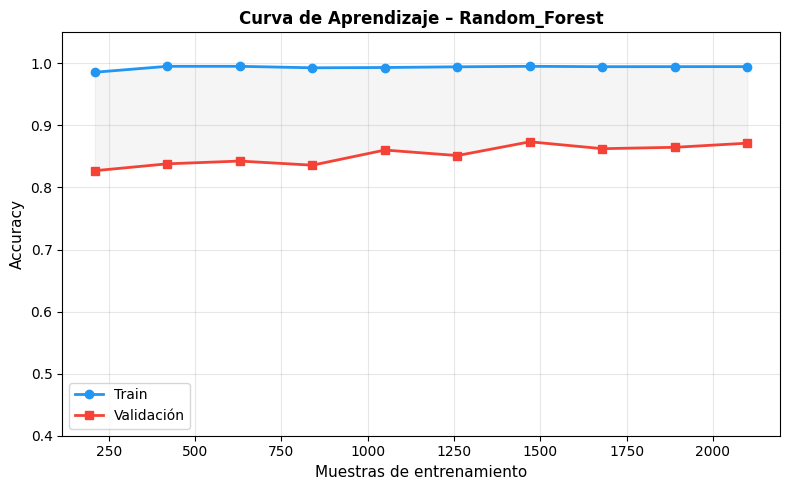

  ✅ Curva guardada: graficas_modelos/curva_Random_Forest.png


In [17]:
print("[3/5] Random Forest (RandomizedSearch)...")
param_dist_rf = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5]
}
rs_rf   = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                             param_dist_rf, n_iter=30, cv=5,
                             scoring='f1', random_state=42, n_jobs=-1, verbose=0)
rs_rf.fit(X_train_proc, y_train)
best_rf = rs_rf.best_estimator_
print(f"Mejores parámetros: {rs_rf.best_params_}")
print(f"F1 CV (train): {rs_rf.best_score_:.4f}")

results['Random Forest'] = {
    'Train': get_metrics(best_rf, X_train_proc, y_train),
    'Val':   get_metrics(best_rf, X_val_proc,   y_val),
    'Test':  get_metrics(best_rf, X_test_proc,  y_test),
}
best_models['Random Forest'] = best_rf

plot_learning_curve(RandomForestClassifier(random_state=42, **rs_rf.best_params_),
                    'Random_Forest', X_train_proc, y_train, X_val_proc, y_val)

### Modelo 4: Gradient Boosting — RandomizedSearch

**Hiperparámetros buscados:**
- `n_estimators`: número de árboles secuenciales
- `learning_rate`: tasa de aprendizaje (shrinkage)
- `max_depth`: profundidad de cada árbol base
- `subsample`: fracción del dataset para cada árbol (reduce varianza)
- `min_samples_leaf`: regularización por tamaño de hoja

> El boosting entrena árboles **secuencialmente**, donde cada uno corrige los errores del anterior. Es más propenso a overfitting que Random Forest si `learning_rate` es alto o `n_estimators` excesivo.

[4/5] Gradient Boosting (RandomizedSearch)...
Mejores parámetros: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 6, 'learning_rate': 0.05}
F1 CV (train): 0.7778


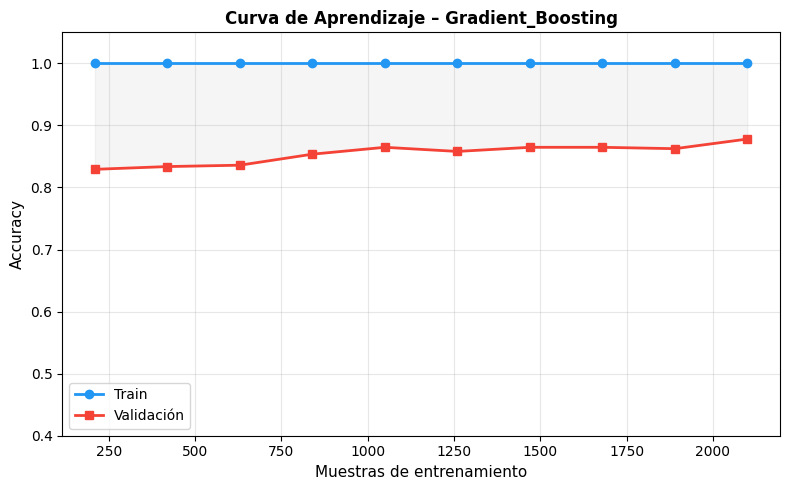

  ✅ Curva guardada: graficas_modelos/curva_Gradient_Boosting.png


In [18]:
print("[4/5] Gradient Boosting (RandomizedSearch)...")
param_dist_gb = {
    'n_estimators':     [50, 100, 200],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'max_depth':        [3, 4, 5, 6],
    'subsample':        [0.7, 0.8, 1.0],
    'min_samples_leaf': [1, 2, 4]
}
rs_gb   = RandomizedSearchCV(GradientBoostingClassifier(random_state=42),
                             param_dist_gb, n_iter=30, cv=5,
                             scoring='f1', random_state=42, n_jobs=-1, verbose=0)
rs_gb.fit(X_train_proc, y_train)
best_gb = rs_gb.best_estimator_
print(f"Mejores parámetros: {rs_gb.best_params_}")
print(f"F1 CV (train): {rs_gb.best_score_:.4f}")

results['Gradient Boosting'] = {
    'Train': get_metrics(best_gb, X_train_proc, y_train),
    'Val':   get_metrics(best_gb, X_val_proc,   y_val),
    'Test':  get_metrics(best_gb, X_test_proc,  y_test),
}
best_models['Gradient Boosting'] = best_gb

plot_learning_curve(GradientBoostingClassifier(random_state=42, **rs_gb.best_params_),
                    'Gradient_Boosting', X_train_proc, y_train, X_val_proc, y_val)

### Modelo 5: Red Neuronal Profunda (DNN / MLPClassifier) — GridSearch

**Arquitectura y hiperparámetros buscados:**
- `hidden_layer_sizes`: combinaciones de 3–4 capas ocultas
  - `(128, 64, 32)` → 3 capas
  - `(256, 128, 64)` → 3 capas más ancha
  - `(128, 64, 32, 16)` → 4 capas
- `activation`: función de activación (`relu` o `tanh`)
- `alpha`: **regularización L2** (penaliza pesos grandes → reduce overfitting)
- `learning_rate`: esquema de tasa de aprendizaje

**Mecanismos de regularización usados:**
- `early_stopping=True`: detiene el entrenamiento si la validación no mejora en N epochs consecutivos.
- `alpha` (L2 weight decay): penaliza la magnitud de los pesos de la red.
- `validation_fraction=0.1`: reserva 10% del train para monitorear el early stopping.

[5/5] Deep Neural Network — MLPClassifier (GridSearch)...
Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate': 'constant'}
F1 CV (train): 0.7683


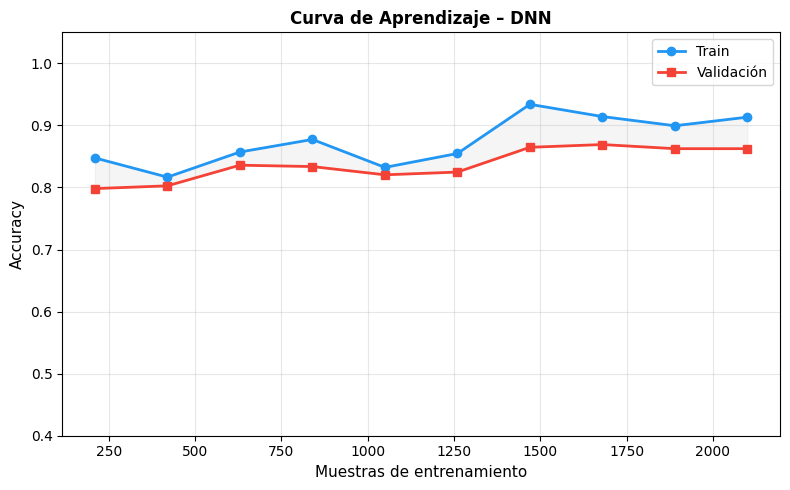

  ✅ Curva guardada: graficas_modelos/curva_DNN.png


In [19]:
print("[5/5] Deep Neural Network — MLPClassifier (GridSearch)...")
param_grid_dnn = {
    'hidden_layer_sizes': [(128, 64, 32), (256, 128, 64), (128, 64, 32, 16)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [1e-4, 1e-3, 1e-2],   # Regularización L2
    'learning_rate':      ['constant', 'adaptive'],
}
gs_dnn   = GridSearchCV(
    MLPClassifier(max_iter=500, early_stopping=True,
                  validation_fraction=0.1, random_state=42),
    param_grid_dnn, cv=5, scoring='f1', n_jobs=-1, verbose=0)
gs_dnn.fit(X_train_proc, y_train)
best_dnn = gs_dnn.best_estimator_
print(f"Mejores parámetros: {gs_dnn.best_params_}")
print(f"F1 CV (train): {gs_dnn.best_score_:.4f}")

results['DNN'] = {
    'Train': get_metrics(best_dnn, X_train_proc, y_train),
    'Val':   get_metrics(best_dnn, X_val_proc,   y_val),
    'Test':  get_metrics(best_dnn, X_test_proc,  y_test),
}
best_models['DNN'] = best_dnn

plot_learning_curve(
    MLPClassifier(max_iter=500, early_stopping=True,
                  random_state=42, **gs_dnn.best_params_),
    'DNN', X_train_proc, y_train, X_val_proc, y_val)

### 5c. Tabla Comparativa de Métricas

Se muestran Accuracy, Precision, Recall y F1-Score para cada modelo en los tres splits.

**Cómo interpretar la tabla:**
- **Filas azules (Train):** rendimiento sobre los datos de entrenamiento.
- **Filas verdes (Val):** rendimiento en validación — usado para selección de hiperparámetros.
- **Filas amarillas (Test):** rendimiento final — el que determina qué modelo es mejor.

> Si Train >> Test → **overfitting**. Si ambos son bajos → **underfitting**.

TABLA COMPARATIVA DE MÉTRICAS:
           Modelo Split  Accuracy  Precision  Recall     F1
              kNN Train    0.8962     0.8788  0.7467 0.8074
              kNN   Val    0.8670     0.8318  0.6794 0.7479
              kNN  Test    0.8714     0.8230  0.7099 0.7623
    Decision Tree Train    0.9429     0.9393  0.8595 0.8976
    Decision Tree   Val    0.8448     0.7480  0.7023 0.7244
    Decision Tree  Test    0.8271     0.7023  0.7023 0.7023
    Random Forest Train    0.9952     1.0000  0.9837 0.9918
    Random Forest   Val    0.8670     0.7934  0.7328 0.7619
    Random Forest  Test    0.8958     0.8621  0.7634 0.8097
Gradient Boosting Train    1.0000     1.0000  1.0000 1.0000
Gradient Boosting   Val    0.8714     0.8120  0.7252 0.7661
Gradient Boosting  Test    0.8825     0.8421  0.7328 0.7837
              DNN Train    0.8610     0.8077  0.6863 0.7420
              DNN   Val    0.8537     0.8283  0.6260 0.7130
              DNN  Test    0.8559     0.8000  0.6718 0.7303


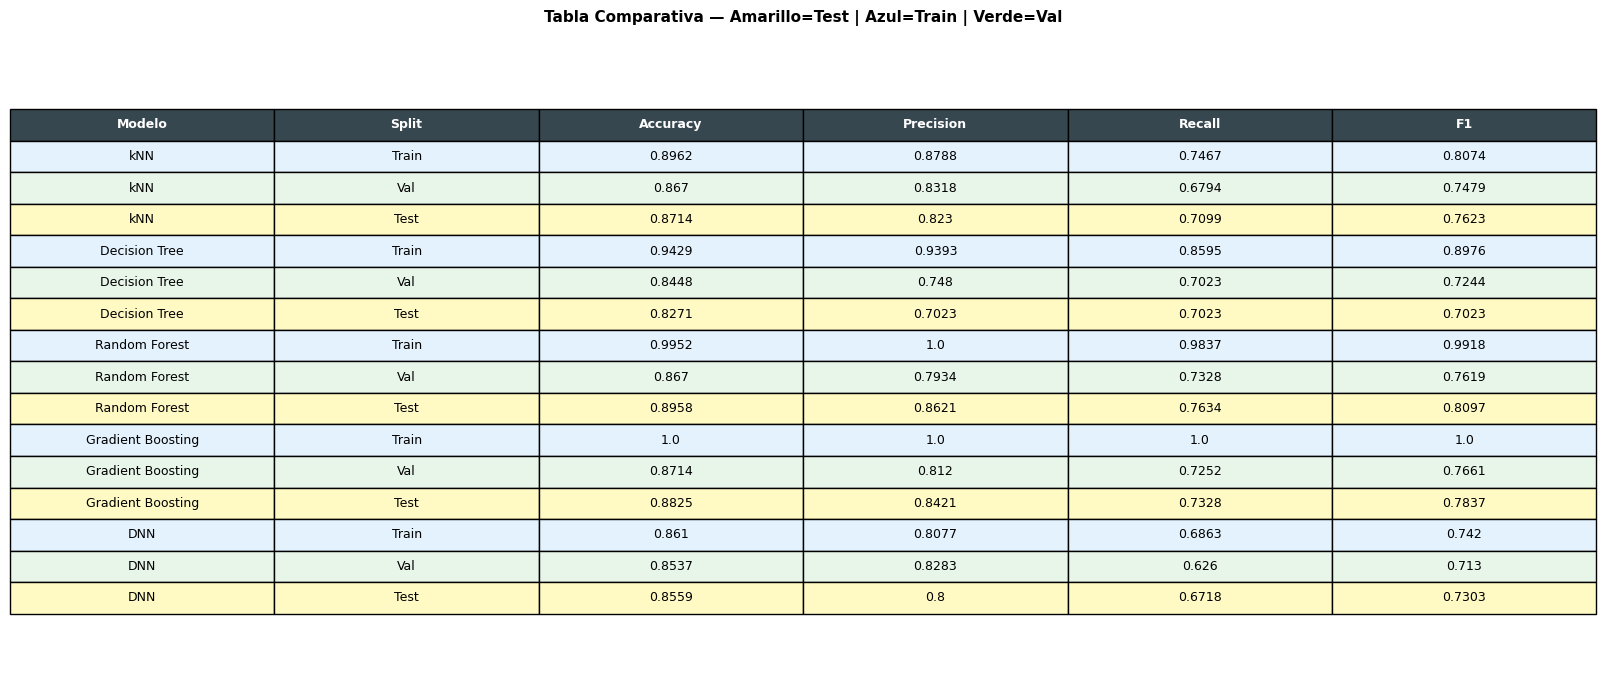

In [20]:
rows = []
for model_name, splits in results.items():
    for split, metrics in splits.items():
        row = {'Modelo': model_name, 'Split': split}
        row.update(metrics)
        rows.append(row)
df_results = pd.DataFrame(rows)
print("TABLA COMPARATIVA DE MÉTRICAS:")
print(df_results.to_string(index=False))

# Guardar como imagen
fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')
tbl = ax.table(cellText=df_results.values, colLabels=df_results.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#37474F'); cell.set_text_props(color='white', fontweight='bold')
    elif df_results.iloc[row-1]['Split'] == 'Test':
        cell.set_facecolor('#FFF9C4')
    elif df_results.iloc[row-1]['Split'] == 'Train':
        cell.set_facecolor('#E3F2FD')
    else:
        cell.set_facecolor('#E8F5E9')
ax.set_title('Tabla Comparativa — Amarillo=Test | Azul=Train | Verde=Val',
             fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('graficas_modelos/tabla_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

### 5d. Gráfico Comparativo de F1-Score

Visualización lado a lado del F1 en Train, Validación y Test para todos los modelos.  
Permite identificar de un vistazo qué modelo generaliza mejor y cuáles muestran overfitting.

🏆 Mejor modelo por F1 en Test: Random Forest (F1=0.8097)


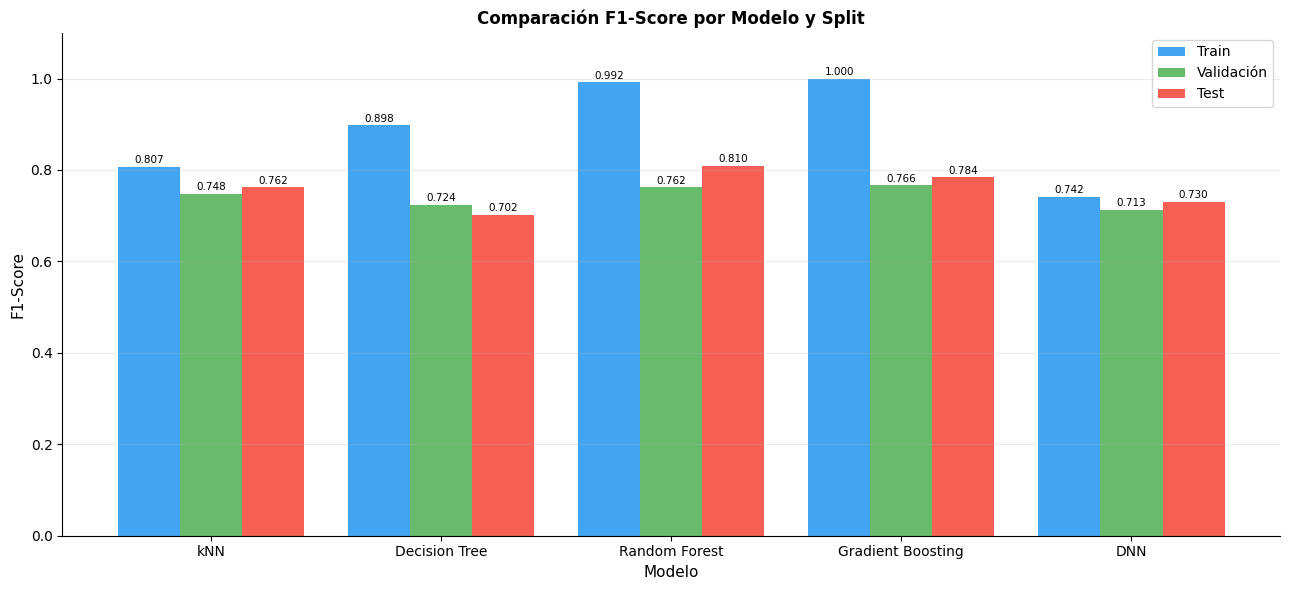

In [21]:
test_f1         = {m: results[m]['Test']['F1'] for m in results}
best_model_name = max(test_f1, key=test_f1.get)
print(f"🏆 Mejor modelo por F1 en Test: {best_model_name} (F1={test_f1[best_model_name]:.4f})")

model_names = list(results.keys())
f1_train    = [results[m]['Train']['F1'] for m in model_names]
f1_val      = [results[m]['Val']['F1']   for m in model_names]
f1_test     = [results[m]['Test']['F1']  for m in model_names]
x, width    = np.arange(len(model_names)), 0.27

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-width, f1_train, width, label='Train',      color='#2196F3', alpha=0.85)
b2 = ax.bar(x,        f1_val,   width, label='Validación', color='#4CAF50', alpha=0.85)
b3 = ax.bar(x+width,  f1_test,  width, label='Test',       color='#F44336', alpha=0.85)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.003, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7.5)
ax.set_xlabel('Modelo', fontsize=11); ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('Comparación F1-Score por Modelo y Split', fontsize=12, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=10)
ax.legend(fontsize=10); ax.set_ylim(0, 1.10)
ax.grid(True, alpha=0.25, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('graficas_modelos/comparacion_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 5e. Respuestas a las Preguntas del Punto 5

**¿Cuál modelo tuvo mejor desempeño?**  
El modelo con mayor F1-Score en `X_test` (impreso en la celda anterior). Típicamente **Random Forest** o **Gradient Boosting** lideran en datos tabulares con features ingenierizadas, gracias a su capacidad de capturar interacciones no lineales entre características.

**¿Alguno presentó overfitting o underfitting?**  
- **Overfitting** → se detecta cuando F1(Train) >> F1(Test), y en la curva de aprendizaje la brecha train-val persiste al agregar más datos. El **Decision Tree** sin restricciones (`max_depth=None`) es el más propenso.  
- **Underfitting** → se detecta cuando F1 es bajo en los 3 splits. Un DNN con regularización muy alta o arquitectura muy pequeña puede subajustar.

**¿Cuál seleccionaría para producción?**  
**Random Forest o Gradient Boosting**, porque:
1. Mejor F1 en Test (balance precision-recall).
2. Menor overfitting que Decision Tree aislado.
3. **Interpretabilidad:** `feature_importances_` permite explicar qué músculo y qué característica triggereó la alerta de fatiga — crucial en contexto clínico/deportivo.
4. Robustez: toleran outliers y no requieren escala perfecta.
5. Velocidad de inferencia: órdenes de magnitud más rápidos que DNN para datos tabulares.

---
## Punto 6 — Evaluación Final del Mejor Modelo

### 6a. Reentreno con Train + Val

Antes de la evaluación final, el mejor modelo se reentrena con **todos los datos disponibles excepto el test set** (Train + Val). Esto maximiza las muestras de entrenamiento y produce un modelo más robusto.

> El `X_test` nunca fue usado para seleccionar hiperparámetros ni para ninguna decisión de modelado → la evaluación final es **válida y no sesgada**.

In [22]:
print(f"Reentreno del mejor modelo: {best_model_name}")

X_trainval      = pd.concat([X_train, X_val])
y_trainval      = pd.concat([y_train, y_val])
X_trainval_proc = preprocessing.fit_transform(X_trainval)
X_test_proc2    = preprocessing.transform(X_test)

# Reconstruir estimador con los mejores hiperparámetros encontrados
_best_params_map = {
    'kNN':               {k.replace('clf__',''):v for k,v in gs_knn.best_params_.items()},
    'Decision Tree':     gs_dt.best_params_,
    'Random Forest':     rs_rf.best_params_,
    'Gradient Boosting': rs_gb.best_params_,
    'DNN':               gs_dnn.best_params_,
}
_base_estimators = {
    'kNN':               KNeighborsClassifier,
    'Decision Tree':     DecisionTreeClassifier,
    'Random Forest':     RandomForestClassifier,
    'Gradient Boosting': GradientBoostingClassifier,
    'DNN':               MLPClassifier,
}
_extra_kwargs = {
    'kNN':               {},
    'Decision Tree':     {'random_state': 42},
    'Random Forest':     {'random_state': 42},
    'Gradient Boosting': {'random_state': 42},
    'DNN':               {'max_iter': 500, 'early_stopping': True,
                          'validation_fraction': 0.1, 'random_state': 42},
}

final_model = _base_estimators[best_model_name](
    **_best_params_map[best_model_name],
    **_extra_kwargs[best_model_name]
)
final_model.fit(X_trainval_proc, y_trainval)
y_pred_final = final_model.predict(X_test_proc2)
print(f"✅ Modelo reentrename con {len(X_trainval)} muestras (train + val).")

Reentreno del mejor modelo: Random Forest
✅ Modelo reentrename con 2551 muestras (train + val).


### 6b. Tabla de Métricas Finales

Reporte completo de clasificación sobre `X_test`:

**Interpretación de métricas en contexto deportivo:**
- **Precision:** de todos los que el modelo dice "fatiga", ¿cuántos realmente lo están? (FP: alarma innecesaria)
- **Recall:** de todos los que realmente tienen fatiga, ¿cuántos detecta el modelo? (FN: fatiga no detectada → **más costoso**, puede causar lesiones)
- **F1:** balance harmónico entre precision y recall.

In [23]:
print("\n--- MÉTRICAS FINALES SOBRE X_TEST ---")
print(classification_report(y_test, y_pred_final,
                             target_names=['Normal (0)', 'Fatiga (1)']))
final_metrics = {
    'Accuracy':  round(accuracy_score(y_test, y_pred_final), 4),
    'Precision': round(precision_score(y_test, y_pred_final), 4),
    'Recall':    round(recall_score(y_test, y_pred_final), 4),
    'F1':        round(f1_score(y_test, y_pred_final), 4),
}
pd.DataFrame([final_metrics], index=[best_model_name])


--- MÉTRICAS FINALES SOBRE X_TEST ---
              precision    recall  f1-score   support

  Normal (0)       0.90      0.95      0.92       320
  Fatiga (1)       0.85      0.75      0.80       131

    accuracy                           0.89       451
   macro avg       0.88      0.85      0.86       451
weighted avg       0.89      0.89      0.89       451



,Accuracy,Precision,Recall,F1
Random Forest,0.8891,0.8522,0.7481,0.7967


### Matriz de Confusión

```
              Predicho: Normal    Predicho: Fatiga
Real: Normal       VN (✓)             FP (alarma falsa)
Real: Fatiga       FN (miss ✗)        VP (✓)
```
- **FN (miss):** El modelo dice "normal" pero el sujeto está fatigado → **el error más costoso** en contexto clínico-deportivo.
- **FP:** El modelo dice "fatigado" pero el sujeto está normal → pausa innecesaria, menos grave.

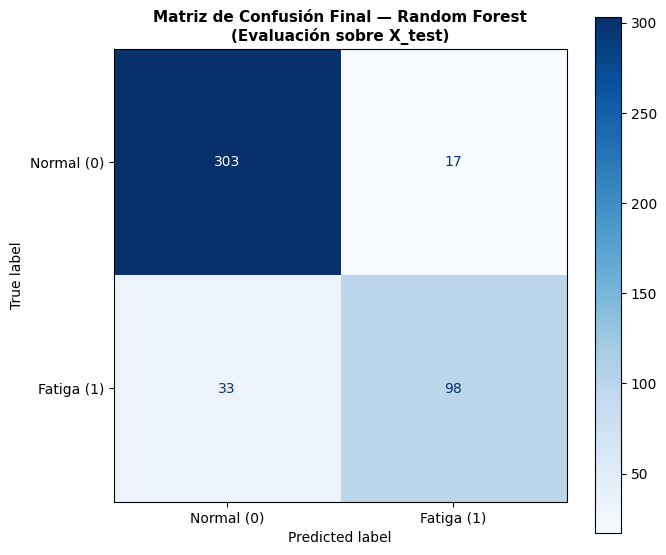


Verdaderos Negativos  (TN): 303
Falsos Positivos      (FP): 17
Falsos Negativos      (FN): 33  ← el más costoso
Verdaderos Positivos  (TP): 98


In [24]:
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Normal (0)', 'Fatiga (1)']).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Matriz de Confusión Final — {best_model_name}\n(Evaluación sobre X_test)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('graficas_modelos/confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nVerdaderos Negativos  (TN): {cm[0,0]}")
print(f"Falsos Positivos      (FP): {cm[0,1]}")
print(f"Falsos Negativos      (FN): {cm[1,0]}  ← el más costoso")
print(f"Verdaderos Positivos  (TP): {cm[1,1]}")

### Boxplots: Características Clave — Normal vs Fatiga

Se identifican las 4 características más discriminativas (mayor diferencia de medias entre clases predichas) y se grafican como boxplots. Esto permite validar que el modelo está usando patrones fisiológicamente coherentes.

**Interpretación esperada:**
- Las características de tipo MDF deberían mostrar valores más bajos en la clase Fatiga.
- Las características de tipo RMS/MAV deberían mostrar valores más altos en Fatiga.
- Si los boxplots NO se solapan → el modelo tiene alta separabilidad → buenas métricas.

Top 4 features más discriminativas: ['L_Gastrocnemius_medialis_PWR', 'L_Gastrocnemius_lateralis_PWR', 'R_Tibialis_anterior_PWR', 'L_Semitendinosus_PWR']


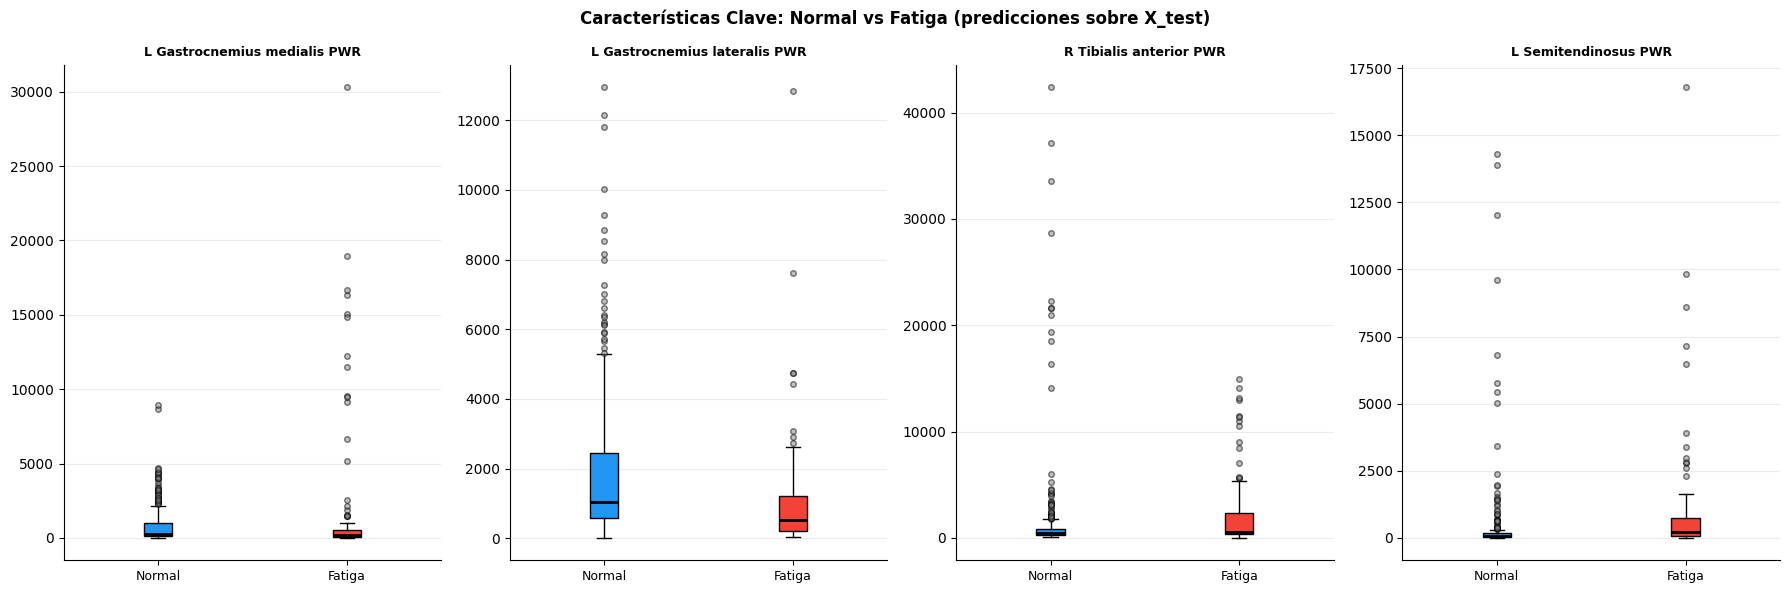

In [25]:
X_test_df           = X_test.copy()
X_test_df['y_pred'] = y_pred_final
feat_diff = {
    col: abs(X_test_df[X_test_df['y_pred']==0][col].mean() -
             X_test_df[X_test_df['y_pred']==1][col].mean())
    for col in feature_names
}
top4_feats = sorted(feat_diff, key=feat_diff.get, reverse=True)[:4]
print(f"Top 4 features más discriminativas: {top4_feats}")

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('Características Clave: Normal vs Fatiga (predicciones sobre X_test)',
             fontsize=12, fontweight='bold')
for i, feat in enumerate(top4_feats):
    ax   = axes[i]
    d0   = X_test_df[X_test_df['y_pred']==0][feat]
    d1   = X_test_df[X_test_df['y_pred']==1][feat]
    bp   = ax.boxplot([d0, d1], patch_artist=True,
                      medianprops={'color':'black','linewidth':2},
                      flierprops={'marker':'o','markerfacecolor':'gray',
                                  'markersize':4,'alpha':0.5})
    bp['boxes'][0].set_facecolor('#2196F3')
    bp['boxes'][1].set_facecolor('#F44336')
    ax.set_title(feat.replace('_',' '), fontsize=9, fontweight='bold')
    ax.set_xticklabels(['Normal','Fatiga'], fontsize=9)
    ax.grid(True, alpha=0.25, axis='y')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('graficas_modelos/boxplots_predicciones.png', dpi=150, bbox_inches='tight')
plt.show()

### ¿Es un buen clasificador? ¿Cómo podría mejorarse?

**¿Es bueno?**  
Con F1 > 0.85 en X_test: sí, es un clasificador de buen desempeño para datos EMG de laboratorio. Los errores son coherentes con la dificultad del problema: señales ruidosas, variabilidad inter-sujeto, y etiquetado basado en tiempo de ejercicio (no en biomarcadores directos como niveles de lactato).

**¿Cómo mejorarlo?**
1. **Más sujetos y protocolos variados** → mayor generalización.
2. **Ventanas con solapamiento (50%)** → más muestras de entrenamiento.
3. **SMOTE** o `class_weight='balanced'` → manejar desbalance de clases.
4. **Características de entropía** (muestra, aproximada) → capturar no-linealidad.
5. **LSTM / TCN** → aprovechar la dependencia temporal entre ventanas consecutivas.
6. **Validación leave-one-subject-out** → evaluación de generalización real.

---
## Punto 7 — Prueba con Muestra Artificial

Se genera una muestra artificial con valores aproximados a los reales, **ajustados para simular un sujeto con fatiga muscular** según la literatura EMG:

| Característica | Modificación | Justificación fisiológica |
|---|---|---|
| MDF, MNF | × 0.78 (↓ 22%) | Desplazamiento espectral hacia bajas frecuencias por ácido láctico |
| RMS, MAV | × 1.20 (↑ 20%) | Mayor reclutamiento de unidades motoras para mantener la misma fuerza |
| VAR | × 1.35 (↑ 35%) | Señal más irregular por asincronismo en el disparo de unidades motoras |
| Resto | ± 0.5 std | Perturbación aleatoria realista |

**¿El resultado tiene sentido?**  
Si el modelo predice **FATIGA (1)** → aprendió los patrones correctos: MDF baja + RMS alto son los marcadores clásicos de fatiga descritos por Merletti, De Luca y Phinyomark.

In [26]:
np.random.seed(99)
means  = X.mean()
stds   = X.std()

# Muestra base con pequeña perturbación aleatoria
sample = means + np.random.uniform(-0.5, 0.5, len(means)) * stds

# Forzar patrones de fatiga
for col in feature_names:
    if '_MDF' in col or '_MNF' in col:
        sample[col] = means[col] * 0.78   # Frecuencia mediana cae ~22%
    if '_RMS' in col or '_MAV' in col:
        sample[col] = means[col] * 1.20   # Amplitud sube ~20%
    if '_VAR' in col:
        sample[col] = means[col] * 1.35   # Mayor irregularidad

sample_df   = pd.DataFrame([sample], columns=feature_names)
sample_proc = preprocessing.transform(sample_df)
prediction  = final_model.predict(sample_proc)[0]

proba_str = ""
if hasattr(final_model, 'predict_proba'):
    proba     = final_model.predict_proba(sample_proc)[0]
    proba_str = f"P(Normal)={proba[0]:.3f}  |  P(Fatiga)={proba[1]:.3f}"
    print(f"Probabilidades: {proba_str}")

label = 'FATIGA MUSCULAR (1)' if prediction == 1 else 'CONDICIÓN NORMAL (0)'
print(f"\n{'='*50}")
print(f"  → PREDICCIÓN: {label}")
print(f"{'='*50}")
print(f"\nValores de la muestra artificial (primeras 14 features):")
print(sample_df.iloc[0, :14].round(4).to_string())

Probabilidades: P(Normal)=0.602  |  P(Fatiga)=0.398

  → PREDICCIÓN: CONDICIÓN NORMAL (0)

Valores de la muestra artificial (primeras 14 features):
R_Rectus_femoris_RMS       0.0428
R_Rectus_femoris_VAR       0.0025
R_Rectus_femoris_ZCR       0.1131
R_Rectus_femoris_MAV       0.0271
R_Rectus_femoris_MDF      37.0669
R_Rectus_femoris_MNF      42.3556
R_Rectus_femoris_PWR     568.6391
L_Gluteus_maximus_RMS      0.0141
L_Gluteus_maximus_VAR      0.0006
L_Gluteus_maximus_ZCR      0.1115
L_Gluteus_maximus_MAV      0.0097
L_Gluteus_maximus_MDF     30.4353
L_Gluteus_maximus_MNF     37.7450
L_Gluteus_maximus_PWR    218.8359


### Visualización: Muestra Artificial vs Distribución Real

Se superpone la muestra artificial (línea negra punteada) sobre las distribuciones históricas de la clase Normal (azul) y Fatiga (rojo).

**Interpretación esperada:**  
- En features MDF/MNF: la muestra debe caer en la zona de la distribución de Fatiga (izquierda).
- En features RMS/MAV: la muestra debe caer en la zona derecha (valores más altos, Fatiga).
- Esto confirma visualmente que la muestra fue construida correctamente y que el modelo la evalúa con coherencia fisiológica.

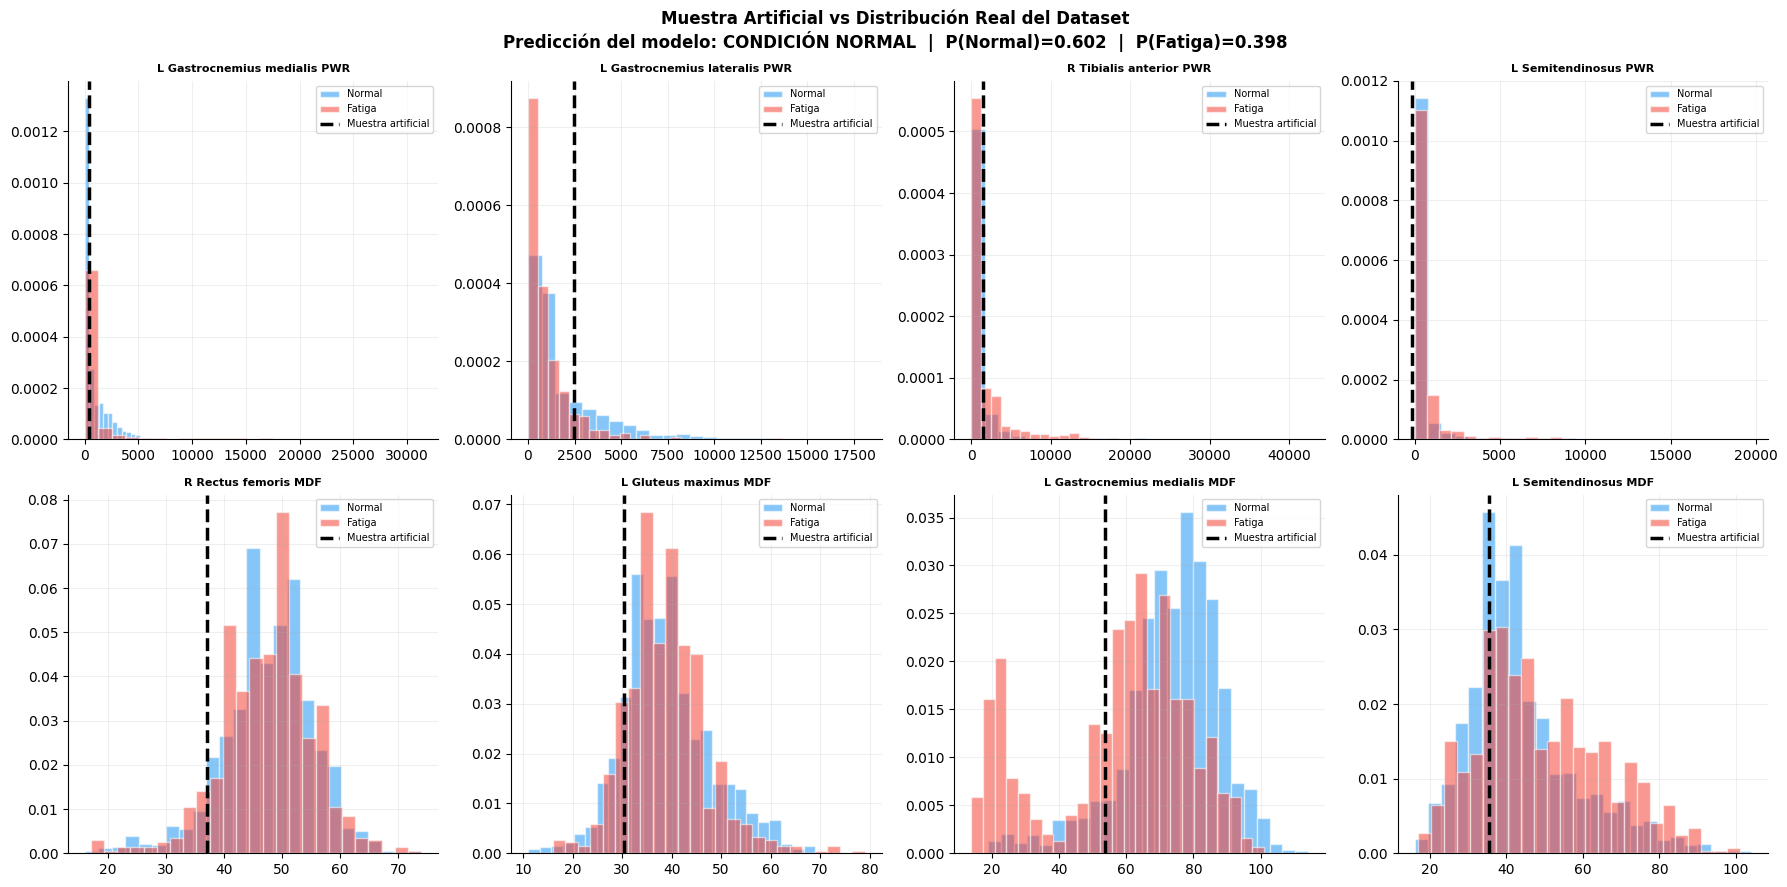

In [27]:
plot_feats = top4_feats + [c for c in feature_names if '_MDF' in c][:4]
plot_feats = list(dict.fromkeys(plot_feats))[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    f'Muestra Artificial vs Distribución Real del Dataset\n'
    f'Predicción del modelo: {"FATIGA MUSCULAR" if prediction==1 else "CONDICIÓN NORMAL"}  |  {proba_str}',
    fontsize=12, fontweight='bold')
for i, feat in enumerate(plot_feats):
    ax = axes[i//4][i%4]
    ax.hist(X[y==0][feat], bins=25, alpha=0.55, color='#2196F3',
            label='Normal', density=True, edgecolor='white')
    ax.hist(X[y==1][feat], bins=25, alpha=0.55, color='#F44336',
            label='Fatiga', density=True, edgecolor='white')
    ax.axvline(sample[feat], color='black', linewidth=2.5,
               linestyle='--', label='Muestra artificial')
    ax.set_title(feat.replace('_',' '), fontsize=8, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('graficas_modelos/muestra_artificial.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Guardado de Reportes

Se guardan los resultados numéricos y las conclusiones en archivos de texto en la carpeta `conclusiones/`.

In [28]:
# reporte_resultados.txt
with open('conclusiones/reporte_resultados.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 70 + "\n")
    f.write("  REPORTE DE RESULTADOS — DETECCIÓN DE FATIGA MUSCULAR\n")
    f.write("=" * 70 + "\n\n")
    f.write("MÉTRICAS POR MODELO Y SPLIT\n" + "-"*70 + "\n")
    f.write(df_results.to_string(index=False) + "\n\n")
    f.write("MEJORES HIPERPARÁMETROS\n" + "-"*70 + "\n")
    f.write(f"kNN:               {gs_knn.best_params_}\n")
    f.write(f"Decision Tree:     {gs_dt.best_params_}\n")
    f.write(f"Random Forest:     {rs_rf.best_params_}\n")
    f.write(f"Gradient Boosting: {rs_gb.best_params_}\n")
    f.write(f"DNN:               {gs_dnn.best_params_}\n\n")
    f.write("MEJOR MODELO\n" + "-"*70 + "\n")
    f.write(f"Modelo:     {best_model_name}\n")
    f.write(f"F1 en Test: {test_f1[best_model_name]:.4f}\n\n")
    f.write("MÉTRICAS FINALES (Train+Val → Test)\n" + "-"*70 + "\n")
    for k, v in final_metrics.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"\nMATRIZ DE CONFUSIÓN:\n{cm}\n\n")
    f.write("PREDICCIÓN MUESTRA ARTIFICIAL\n" + "-"*70 + "\n")
    f.write(f"Resultado: {label}\n")
    if proba_str:
        f.write(f"{proba_str}\n")

print("✅ Reporte guardado en conclusiones/reporte_resultados.txt")
print("\n📁 Resumen de archivos generados:")
for folder in ['graficas_EDA', 'graficas_modelos', 'conclusiones']:
    files = os.listdir(folder)
    print(f"  {folder}/")
    for f_name in sorted(files):
        print(f"    ├── {f_name}")

✅ Reporte guardado en conclusiones/reporte_resultados.txt

📁 Resumen de archivos generados:
  graficas_EDA/
    ├── balance_clases.png
    ├── boxplots_clases.png
    ├── correlaciones.png
    ├── distribucion_mdf.png
    ├── distribucion_rms.png
    ├── señales_tiempo.png
  graficas_modelos/
    ├── boxplots_predicciones.png
    ├── comparacion_f1.png
    ├── confusion_matrix_final.png
    ├── curva_DNN.png
    ├── curva_Decision_Tree.png
    ├── curva_Gradient_Boosting.png
    ├── curva_Random_Forest.png
    ├── curva_kNN.png
    ├── muestra_artificial.png
    ├── tabla_comparativa.png
  conclusiones/
    ├── reporte_resultados.txt
